In [4]:
"""Notebook settings and imports"""

%load_ext autoreload
%autoreload 2
# %flow mode reactive

import datetime
import os
import pathlib
import pickle
import sys
from collections import defaultdict
from colorsys import hls_to_rgb, rgb_to_hls
from contextlib import contextmanager
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import plotly
import plotly.express as px
import plotly.graph_objs as go
import seaborn as sns
from numpy.lib.stride_tricks import as_strided
from plotly.subplots import make_subplots
from scipy import stats
from tqdm.notebook import tqdm

import aeon
import datajoint as dj
from aeon.dj_pipeline.analysis.block_analysis import *
from aeon.dj_pipeline import acquisition, streams
from aeon.schema.schemas import social02, social03

cwd = os.getcwd()
project_path = os.path.join(cwd, "ProjectAeon", "aeon_scratchpad", "aeon_analysis", "aeon_methods_paper")
sys.path.append(project_path)
from data_io_utils import load_data_from_parquet, excise_swaps

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
plt.style.use("seaborn-whitegrid")
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 18
plt.rcParams["xtick.labelsize"] = 15
plt.rcParams["ytick.labelsize"] = 15
plt.rcParams["legend.title_fontsize"] = 15
plt.rcParams["legend.fontsize"] = 14

## Definitions

In [5]:
subject_colors = plotly.colors.qualitative.Dark24
patch_colors = plotly.colors.qualitative.Light24
patch_markers = [
    "circle",
    "bowtie",
    "square",
    "hourglass",
    "diamond",
    "cross",
    "x",
    "triangle",
    "star",
]
patch_markers_symbols = ["●", "⧓", "■", "⧗", "♦", "✖", "×", "▲", "★"]
patch_markers_dict = {
    marker: symbol for marker, symbol in zip(patch_markers, patch_markers_symbols)
}
patch_markers_linestyles = ["solid", "dash", "dot", "dashdot", "longdashdot"]
subject_markers_linestyles = patch_markers_linestyles.copy()

In [181]:
experiments = [
    {"name": "social0.2-aeon3", "presocial_start": '2024-01-31 11:00:00', "presocial_end": '2024-02-08 15:00:00', "social_start": '2024-02-09 16:00:00', "social_end": '2024-02-23 13:00:00', "postsocial_start": '2024-02-25 17:00:00', "postsocial_end": '2024-03-02 14:00:00'},
    {"name": "social0.2-aeon4", "presocial_start": '2024-01-31 11:00:00', "presocial_end": '2024-02-08 15:00:00', "social_start": '2024-02-09 17:00:00', "social_end": '2024-02-23 12:00:00', "postsocial_start": '2024-02-25 18:00:00', "postsocial_end": '2024-03-02 13:00:00'},
    # {"name": "social0.3-aeon3", "presocial_start": '2024-06-08 19:00:00', "presocial_end": '2024-06-17 13:00:00', "social_start": '2024-06-25 11:00:00', "social_end": '2024-07-06 13:00:00', "postsocial_start": '2024-07-07 16:00:00', "postsocial_end": '2024-07-14 14:00:00'},
    {"name": "social0.3-aeon4", "presocial_start": '2024-06-08 19:00:00', "presocial_end": '2024-06-17 14:00:00', "social_start": '2024-06-19 12:00:00', "social_end": '2024-07-03 14:00:00', "postsocial_start": '2024-07-04 11:00:00', "postsocial_end": '2024-07-13 12:00:00'},
    {"name": "social0.4-aeon3", "presocial_start": '2024-08-16 17:00:00', "presocial_end": '2024-08-24 10:00:00', "social_start": '2024-08-28 11:00:00', "social_end": '2024-09-09 13:00:00', "postsocial_start": '2024-09-09 18:00:00', "postsocial_end": '2024-09-22 16:00:00'},
    {"name": "social0.4-aeon4", "presocial_start": '2024-08-16 15:00:00', "presocial_end": '2024-08-24 10:00:00', "social_start": '2024-08-28 10:00:00', "social_end": '2024-09-09 01:00:00', "postsocial_start": '2024-09-09 15:00:00', "postsocial_end": '2024-09-22 16:00:00'}
]

periods = ["presocial", "social", "postsocial"]

In [201]:
cm2px = 5.2  # 1 cm = 5.2 px roughly in aeon arenas
light_off, light_on = 7, 20  # 7am to 7pm
data_dir = Path("/ceph/aeon/aeon/code/scratchpad/methods_paper_data")

## Solo vs. Social Behaviours

### Exploring

#### Distance travelled

In [ ]:
# Final df:
# rows = hour-datetime,
# columns = distance, exp, social-bool, subject, light-bool

dist_trav_hour_df = pd.DataFrame(columns=["hour", "distance", "exp", "social", "subject", "light"])

In [103]:
# For each period
  # Load pos data
  # Split into individual dfs
  # If social, excise swaps
  # Smooth down to 1s
  # Calculate hour-by-hour distance traveled, and put into final df

exp_pbar = tqdm(experiments, desc="Experiments", position=0, leave=True)
for exp in exp_pbar:
    period_pbar = tqdm(periods, desc="Periods", position=1, leave=True)
    for period in period_pbar:
        pos_df = load_data_from_parquet(
            experiment_name = exp["name"],
            period=period,
            data_type="position",
            data_dir=data_dir,
            set_time_index=True
        )
        for subject in pos_df["identity_name"].unique():
            pos_df_subj = pos_df[pos_df["identity_name"] == subject]
            pos_df_subj = pos_df_subj.resample("200ms").first().dropna(subset=["x"])
            pos_df_subj[["x", "y"]] = pos_df_subj[["x", "y"]].rolling("1s").mean()
            pos_df_subj = pos_df_subj.resample("1s").first().dropna(subset=["x"])
            if period == "social":
                pos_df_subj = excise_swaps(pos_df_subj, max_speed=500)
            pos_df_subj["distance"] = np.sqrt(
                (pos_df_subj["x"].diff() ** 2) + (pos_df_subj["y"].diff() ** 2)
            )
            pos_df_subj.at[pos_df_subj.index[0], "distance"] = 0
            pos_df_subj["distance"] /= (cm2px * 100)  # convert to m
            pos_df_subj["hour"] = pos_df_subj.index.floor("h")
            pos_df_subj_hour = pos_df_subj.groupby("hour")["distance"].sum().reset_index()
            pos_df_subj_hour["exp"] = exp["name"]
            pos_df_subj_hour["social"] = period == "social"
            pos_df_subj_hour["subject"] = subject
            hour = pos_df_subj_hour["hour"].dt.hour
            pos_df_subj_hour["light"] = ~((hour > light_off) & (hour < light_on))
            dist_trav_hour_df = pd.concat([dist_trav_hour_df, pos_df_subj_hour], ignore_index=True)

Experiments:   0%|          | 0/4 [00:00<?, ?it/s]

Periods:   0%|          | 0/3 [00:00<?, ?it/s]

Found 1 matching files
Loading /ceph/aeon/aeon/code/scratchpad/methods_paper_data/social0.2-aeon4_presocial_position.parquet...


  Loaded 27348830 rows
Combined data: 27348830 rows
Found 1 matching files
Loading /ceph/aeon/aeon/code/scratchpad/methods_paper_data/social0.2-aeon4_social_position.parquet...
  Loaded 101766326 rows
Combined data: 101766326 rows
Found 1 matching files
Loading /ceph/aeon/aeon/code/scratchpad/methods_paper_data/social0.2-aeon4_postsocial_position.parquet...
  Loaded 25310474 rows
Combined data: 25310474 rows


Periods:   0%|          | 0/3 [00:00<?, ?it/s]

Found 1 matching files
Loading /ceph/aeon/aeon/code/scratchpad/methods_paper_data/social0.3-aeon4_presocial_position.parquet...
  Loaded 34229451 rows
Combined data: 34229451 rows
Found 1 matching files
Loading /ceph/aeon/aeon/code/scratchpad/methods_paper_data/social0.3-aeon4_social_position.parquet...
  Loaded 84272009 rows
Combined data: 84272009 rows
Found 1 matching files
Loading /ceph/aeon/aeon/code/scratchpad/methods_paper_data/social0.3-aeon4_postsocial_position.parquet...
  Loaded 36088275 rows
Combined data: 36088275 rows


Periods:   0%|          | 0/3 [00:00<?, ?it/s]

Found 1 matching files
Loading /ceph/aeon/aeon/code/scratchpad/methods_paper_data/social0.4-aeon3_presocial_position.parquet...
  Loaded 33428889 rows
Combined data: 33428889 rows
Found 1 matching files
Loading /ceph/aeon/aeon/code/scratchpad/methods_paper_data/social0.4-aeon3_social_position.parquet...
  Loaded 93997812 rows
Combined data: 93997812 rows
Found 1 matching files
Loading /ceph/aeon/aeon/code/scratchpad/methods_paper_data/social0.4-aeon3_postsocial_position.parquet...
  Loaded 36160347 rows
Combined data: 36160347 rows


Periods:   0%|          | 0/3 [00:00<?, ?it/s]

Found 1 matching files
Loading /ceph/aeon/aeon/code/scratchpad/methods_paper_data/social0.4-aeon4_presocial_position.parquet...
  Loaded 33813989 rows
Combined data: 33813989 rows
Found 1 matching files
Loading /ceph/aeon/aeon/code/scratchpad/methods_paper_data/social0.4-aeon4_social_position.parquet...
  Loaded 75860467 rows
Combined data: 75860467 rows
Found 1 matching files
Loading /ceph/aeon/aeon/code/scratchpad/methods_paper_data/social0.4-aeon4_postsocial_position.parquet...
  Loaded 39079270 rows
Combined data: 39079270 rows


In [110]:
display(dist_trav_hour_df)

# # Save as parquet
# dist_trav_hour_df.to_parquet(
#     data_dir / "for_plots" / "dist_trav_hour_df.parquet",
#     engine="pyarrow",
#     compression="snappy",
#     index=False,
# )

# # Load the parquet file
# dist_trav_hour_df2 = pd.read_parquet(
#     data_dir / "for_plots" / "dist_trav_hour_df.parquet",
#     engine="pyarrow",
# )
# display(dist_trav_hour_df2)

,hour,distance,exp,social,subject,light
0,2024-01-31 11:00:00,214.375787,social0.2-aeon3,False,BAA-1104045,False
1,2024-01-31 12:00:00,358.672416,social0.2-aeon3,False,BAA-1104045,False
2,2024-01-31 13:00:00,301.952548,social0.2-aeon3,False,BAA-1104045,False
3,2024-01-31 14:00:00,284.154738,social0.2-aeon3,False,BAA-1104045,False
4,2024-01-31 15:00:00,420.268372,social0.2-aeon3,False,BAA-1104045,False
...,...,...,...,...,...,...
4840,2024-09-22 13:00:00,263.921865,social0.4-aeon4,False,BAA-1104797,False
4841,2024-09-22 14:00:00,316.511526,social0.4-aeon4,False,BAA-1104797,False
4842,2024-09-22 15:00:00,281.001766,social0.4-aeon4,False,BAA-1104797,False
4843,2024-09-22 16:00:00,171.733688,social0.4-aeon4,False,BAA-1104797,False


In [ ]:
# Define the possible combos of social and light
combos = [
    (True, True),   # Social + Light
    (True, False),  # Social + Dark
    (False, True),  # Solo + Light
    (False, False)  # Solo + Dark
]

# Define colors based on light condition (light=blue, dark=orange)
colors = {
    True: "#1f77b4",   # Blue for light conditions
    False: "#ff7f0e"   # Orange for dark conditions
}

# Define hatch patterns based on social condition
hatches = {
    True: "///",   # Hatched pattern for social
    False: None    # No pattern (solid) for solo
}

labels = ["Social-Light", "Social-Dark", "Solo-Light", "Solo-Dark"]

/nfs/nhome/live/jbhagat/mambaforge/envs/aeon/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nfs/nhome/live/jbhagat/mambaforge/envs/aeon/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nfs/nhome/live/jbhagat/mambaforge/envs/aeon/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nfs/nhome/live/jbhagat/mambaforge/envs/aeon/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWar

(0.0, 0.2)

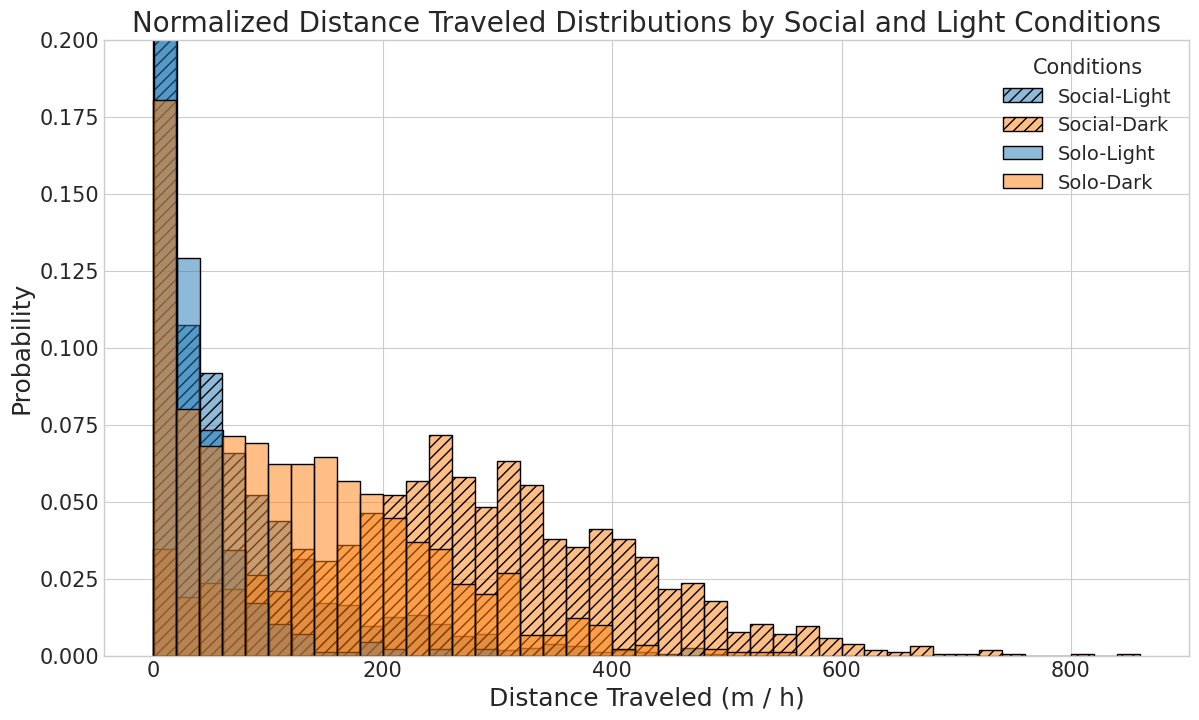

In [172]:
"""Hists."""

fig, ax = plt.subplots(figsize=(14, 8))

# Plot histograms for each combination
for i, (social_val, light_val) in enumerate(combos):
    # Filter data for this combination
    subset = dist_trav_hour_df[
        (dist_trav_hour_df["social"] == social_val)
        & (dist_trav_hour_df["light"] == light_val)
    ]
    # Plot normalized histogram
    hist = sns.histplot(
        data=subset,
        x="distance",
        stat="probability",  # This normalizes the histogram
        alpha=0.5,
        color=colors[light_val],
        label=labels[i],
        # kde=True,  # Add kernel density estimate
        common_norm=False,  # Ensure each histogram is normalized separately
        axes=ax,
        binwidth=20
    )

    # Set hatch pattern for bars
    if hatches[social_val]:
        for bar in hist.patches:
            bar.set_hatch(hatches[social_val])

ax.set_title("Normalized Distance Traveled Distributions by Social and Light Conditions")
ax.set_xlabel("Distance Traveled (m / h)")
ax.set_ylabel("Probability")
ax.legend(title="Conditions")

ax.set_ylim(0, 0.2)

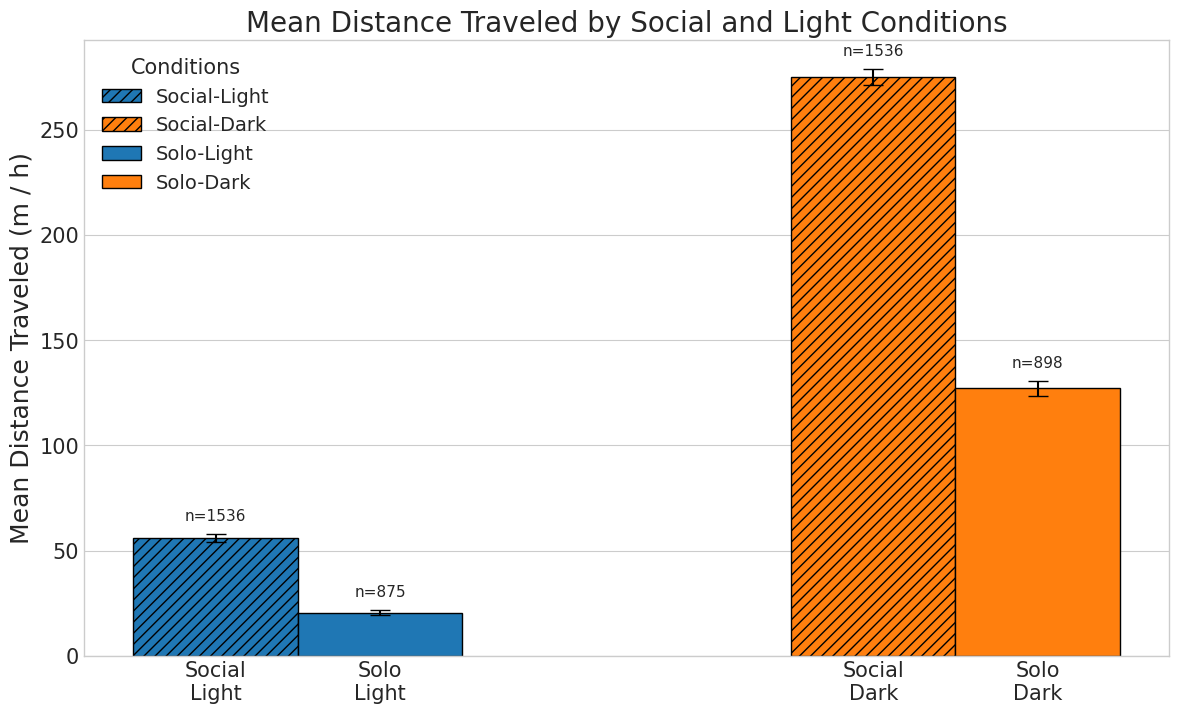

In [186]:
"""Bars."""

fig, ax = plt.subplots(figsize=(14, 8))

summary_data = []
for social_val in [True, False]:
    for light_val in [True, False]:
        subset = dist_trav_hour_df[
            (dist_trav_hour_df["social"] == social_val)
            & (dist_trav_hour_df["light"] == light_val)
        ]
        mean_dist = subset["distance"].mean()
        sem_dist = subset["distance"].sem()
        n_samples = len(subset)
        summary_data.append({
            "social": social_val,
            "light": light_val,
            "mean_distance": mean_dist,
            "sem": sem_dist,
            "condition": f"{'Social' if social_val else 'Solo'}-{'Light' if light_val else 'Dark'}",
            "n": n_samples
        })
summary_df = pd.DataFrame(summary_data)

# Set up positions for the bars
bar_width = 0.5
x_pos = np.array([0.25, 2.25, 0.75, 2.75])  # create two groups with a gap in the middle

# Plot bars
for i, row in enumerate(summary_data):
    pos = x_pos[i]
    social_val = row["social"]
    light_val = row["light"]

    bar = ax.bar(
        pos,
        row["mean_distance"],
        bar_width,
        yerr=row["sem"],
        color=colors[light_val],
        edgecolor="black",
        capsize=7,
        label=row["condition"]
    )

    # Apply hatching for social conditions
    if hatches[social_val]:
        bar[0].set_hatch(hatches[social_val])

    # Add sample size as text above each bar
    sample_size_txt = ax.text(
        pos, row["mean_distance"] + row["sem"] + 5, f"n={row['n']}", ha="center", va="bottom"
    )
    sample_size_txt.set_fontsize(11)

ax.set_ylabel("Mean Distance Traveled (m / h)")
ax.set_xticks(x_pos)
ax.set_xticklabels(["Social\nLight", "Social\nDark", "Solo\nLight", "Solo\nDark"])
ax.set_title("Mean Distance Traveled by Social and Light Conditions")
ax.legend(title="Conditions", loc="upper left")
ax.xaxis.grid(False)

#### Bouts

In [202]:
# Final df:
# rows = hour-datetime,
# columns = n_bouts, exp, social-bool, subject, light-bool

explore_hour_df = pd.DataFrame(columns=["hour", "n_bouts", "exp", "social", "subject", "light"])
explore_dur_df = pd.DataFrame(columns=["start", "duration", "exp", "social", "subject", "light"])

In [ ]:
exp_pbar = tqdm(experiments, desc="Experiments", position=0, leave=True)
for exp in exp_pbar:
    period_pbar = tqdm(periods, desc="Periods", position=1, leave=False)
    for period in period_pbar:
        explore_bouts_df = load_data_from_parquet(
            experiment_name = exp["name"],
            period=period,
            data_type="explore",
            data_dir=data_dir,
            set_time_index=True
        )
        for subject in explore_bouts_df["subject"].unique():
            explore_df_subj = explore_bouts_df[explore_bouts_df["subject"] == subject]
            explore_df_subj["hour"] = explore_df_subj["start"].dt.floor("h")
            min_hour, max_hour = explore_df_subj["hour"].min(), explore_df_subj["hour"].max()
            complete_hours = pd.DataFrame(
                {"hour": pd.date_range(start=min_hour, end=max_hour, freq="h")}
            )
            hour_counts = explore_df_subj.groupby("hour").size().reset_index(name="n_bouts")
            explore_df_subj_hour = pd.merge(
                complete_hours, hour_counts, on="hour", how="left"
            ).fillna(0)
            explore_df_subj_hour["n_bouts"] = explore_df_subj_hour["n_bouts"].astype(int)
            explore_df_subj_hour["exp"] = exp["name"]
            explore_df_subj_hour["social"] = period == "social"
            explore_df_subj_hour["subject"] = subject
            hour = explore_df_subj_hour["hour"].dt.hour
            explore_df_subj_hour["light"] = ~((hour > light_off) & (hour < light_on))
            explore_hour_df = pd.concat([explore_hour_df, explore_df_subj_hour], ignore_index=True)

            explore_dur_subj = explore_df_subj[["start", "duration"]].copy()
            explore_dur_subj["exp"] = exp["name"]
            explore_dur_subj["social"] = period == "social"
            explore_dur_subj["subject"] = subject
            hour = explore_dur_subj["start"].dt.hour
            explore_dur_subj["light"] = ~((hour > light_off) & (hour < light_on))
            explore_dur_df = pd.concat([explore_dur_df, explore_dur_subj], ignore_index=True)

explore_dur_df["duration"] = explore_dur_df["duration"].dt.total_seconds() / 60
explore_dur_df = explore_dur_df[explore_dur_df["duration"] < 120]

In [156]:
# display(explore_hour_df)

# # Save as parquet
# explore_hour_df.to_parquet(
#     data_dir / "for_plots" / "explore_hour_df.parquet",
#     engine="pyarrow",
#     compression="snappy",
#     index=False,
# )

# Load the parquet file
explore_hour_df = pd.read_parquet(
    data_dir / "for_plots" / "explore_hour_df.parquet",
    engine="pyarrow",
)
display(explore_hour_df)

,hour,n_bouts,exp,social,subject,light
0,2024-01-31 11:00:00,5,social0.2-aeon3,False,BAA-1104045,False
1,2024-01-31 12:00:00,12,social0.2-aeon3,False,BAA-1104045,False
2,2024-01-31 13:00:00,7,social0.2-aeon3,False,BAA-1104045,False
3,2024-01-31 14:00:00,5,social0.2-aeon3,False,BAA-1104045,False
4,2024-01-31 15:00:00,12,social0.2-aeon3,False,BAA-1104045,False
...,...,...,...,...,...,...
4938,2024-09-22 12:00:00,1,social0.4-aeon4,False,BAA-1104797,False
4939,2024-09-22 13:00:00,5,social0.4-aeon4,False,BAA-1104797,False
4940,2024-09-22 14:00:00,2,social0.4-aeon4,False,BAA-1104797,False
4941,2024-09-22 15:00:00,6,social0.4-aeon4,False,BAA-1104797,False


/nfs/nhome/live/jbhagat/mambaforge/envs/aeon/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nfs/nhome/live/jbhagat/mambaforge/envs/aeon/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nfs/nhome/live/jbhagat/mambaforge/envs/aeon/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nfs/nhome/live/jbhagat/mambaforge/envs/aeon/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWar

(0.0, 15.0)

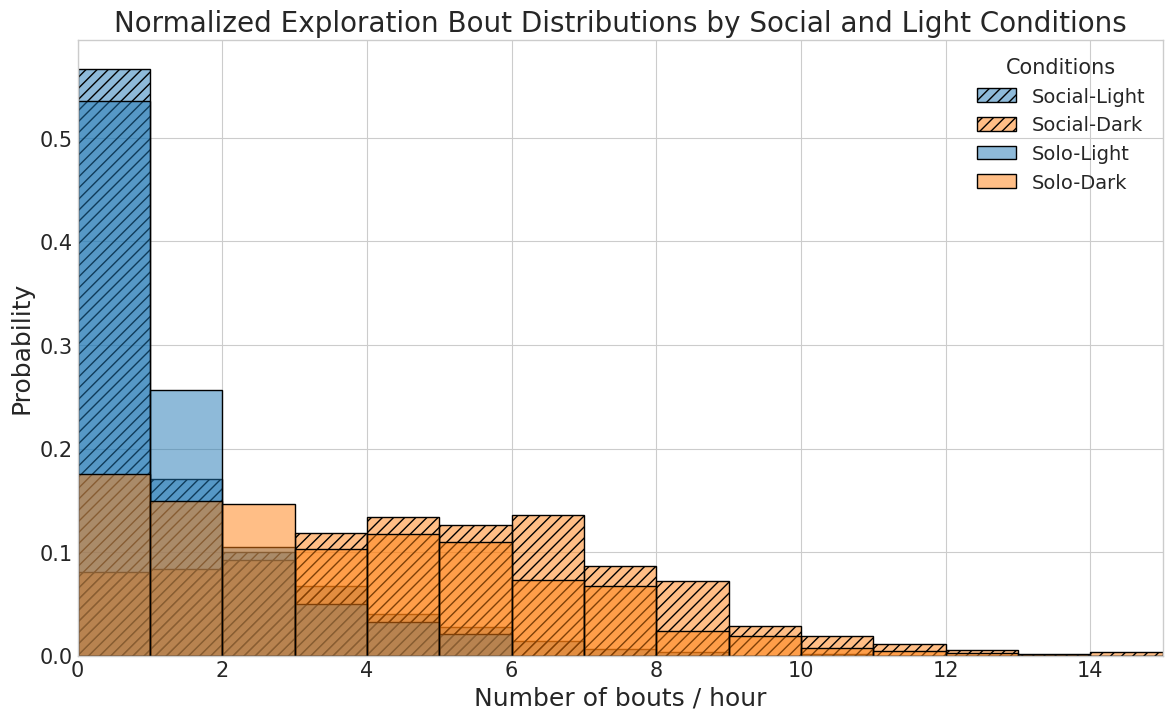

In [205]:
"""Plot hist of bouts per hour"""

fig, ax = plt.subplots(figsize=(14, 8))

# Plot histograms for each combination
for i, (social_val, light_val) in enumerate(combos):
    subset = explore_hour_df[
        (explore_hour_df["social"] == social_val)
        & (explore_hour_df["light"] == light_val)
    ]
    # Plot normalized histogram
    hist = sns.histplot(
        data=subset,
        x="n_bouts",
        stat="probability",
        alpha=0.5,
        color=colors[light_val],
        label=labels[i],
        # kde=True,  # Add kernel density estimate
        common_norm=False,  # Ensure each histogram is normalized separately
        axes=ax,
        binwidth=1
    )

    # Set hatch pattern for bars
    if hatches[social_val]:
        for bar in hist.patches:
            bar.set_hatch(hatches[social_val])

ax.set_title("Normalized Exploration Bout Distributions by Social and Light Conditions")
ax.set_xlabel("Number of bouts / hour")
ax.set_ylabel("Probability")
ax.legend(title="Conditions")

ax.set_xticks(np.arange(0, 15, 2))
ax.set_xlim(0, 15)

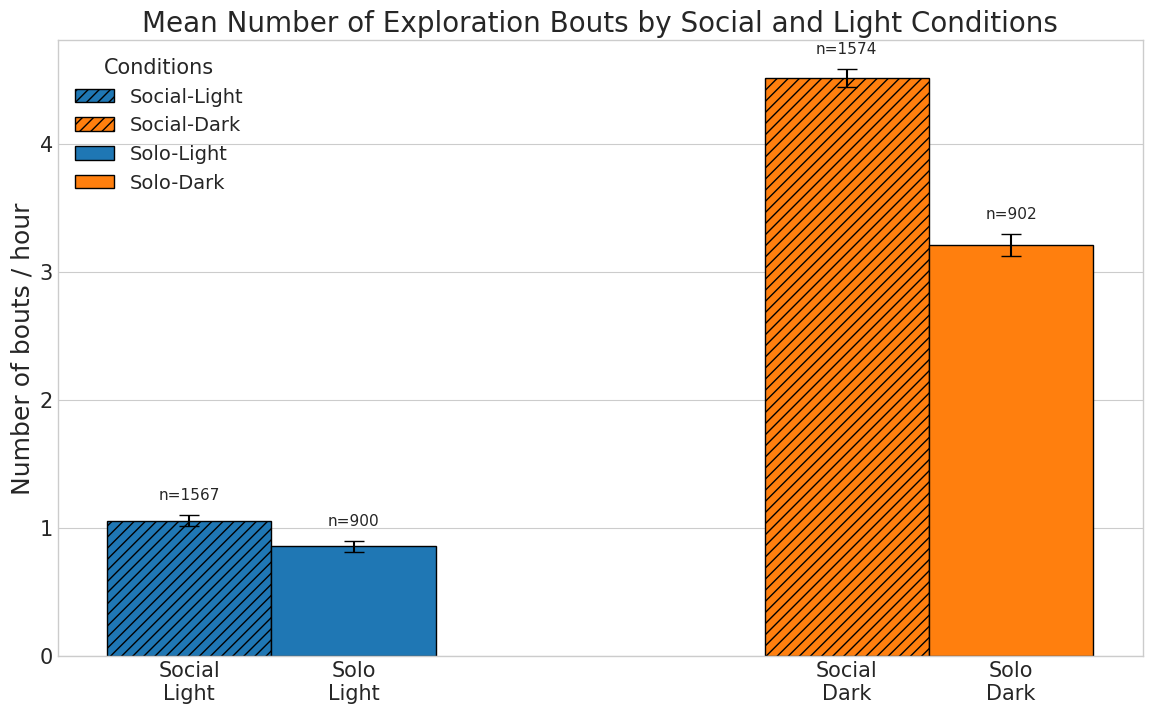

In [206]:
"""Plot bars of bouts per hour"""

fig, ax = plt.subplots(figsize=(14, 8))

summary_data = []
for social_val in [True, False]:
    for light_val in [True, False]:
        subset = explore_hour_df[
            (explore_hour_df["social"] == social_val)
            & (explore_hour_df["light"] == light_val)
        ]
        mean_n_bouts = subset["n_bouts"].mean()
        sem_n_bouts = subset["n_bouts"].sem()
        n_samples = len(subset)
        summary_data.append({
            "social": social_val,
            "light": light_val,
            "mean_n_bouts": mean_n_bouts,
            "sem": sem_n_bouts,
            "condition": f"{'Social' if social_val else 'Solo'}-{'Light' if light_val else 'Dark'}",
            "n": n_samples
        })
summary_df = pd.DataFrame(summary_data)

# Set up positions for the bars
bar_width = 0.5
x_pos = np.array([0.25, 2.25, 0.75, 2.75])  # create two groups with a gap in the middle

# Plot bars
for i, row in enumerate(summary_data):
    pos = x_pos[i]
    social_val = row["social"]
    light_val = row["light"]

    bar = ax.bar(
        pos,
        row["mean_n_bouts"],
        bar_width,
        yerr=row["sem"],
        color=colors[light_val],
        edgecolor="black",
        capsize=7,
        label=row["condition"]
    )

    # Apply hatching for social conditions
    if hatches[social_val]:
        bar[0].set_hatch(hatches[social_val])

    # Add sample size as text above each bar
    sample_size_txt = ax.text(
        pos, row["mean_n_bouts"] + row["sem"] + 0.1, f"n={row['n']}", ha="center", va="bottom"
    )
    sample_size_txt.set_fontsize(11)

ax.set_title("Mean Number of Exploration Bouts by Social and Light Conditions")
ax.set_ylabel("Number of bouts / hour")
ax.set_xticks(x_pos)
ax.set_xticklabels(["Social\nLight", "Social\nDark", "Solo\nLight", "Solo\nDark"])
ax.legend(title="Conditions", loc="upper left")
ax.xaxis.grid(False)

/nfs/nhome/live/jbhagat/mambaforge/envs/aeon/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nfs/nhome/live/jbhagat/mambaforge/envs/aeon/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nfs/nhome/live/jbhagat/mambaforge/envs/aeon/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nfs/nhome/live/jbhagat/mambaforge/envs/aeon/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWar

(0.0, 0.3)

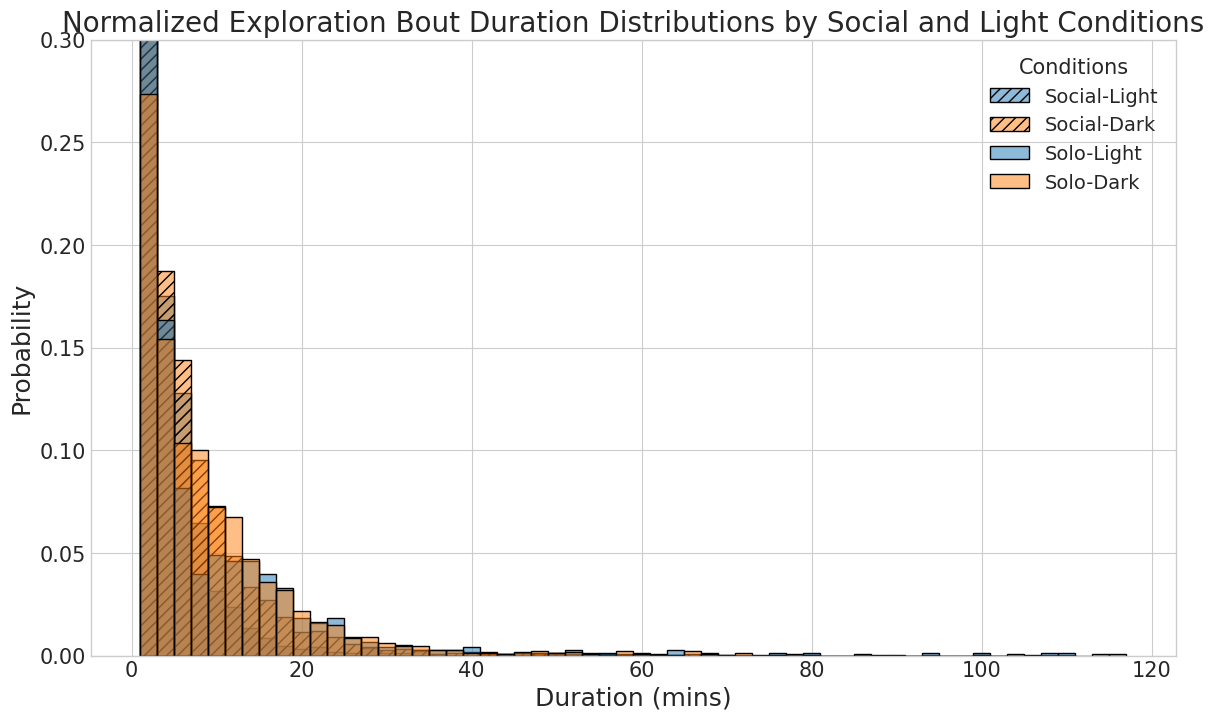

In [234]:
"""Plot hist of durations of bouts."""

fig, ax = plt.subplots(figsize=(14, 8))

# Plot histograms for each combination
for i, (social_val, light_val) in enumerate(combos):
    subset = explore_dur_df[
        (explore_dur_df["social"] == social_val)
        & (explore_dur_df["light"] == light_val)
    ]
    # Plot normalized histogram
    hist = sns.histplot(
        data=subset,
        x="duration",
        stat="probability",
        alpha=0.5,
        color=colors[light_val],
        label=labels[i],
        # kde=True,  # Add kernel density estimate
        common_norm=False,  # Ensure each histogram is normalized separately
        axes=ax,
        binwidth=2
    )

    # Set hatch pattern for bars
    if hatches[social_val]:
        for bar in hist.patches:
            bar.set_hatch(hatches[social_val])

ax.set_title("Normalized Exploration Bout Duration Distributions by Social and Light Conditions")
ax.set_xlabel("Duration (mins)")
ax.set_ylabel("Probability")
ax.legend(title="Conditions")

# ax.set_xlim(0, 60)
ax.set_ylim(0, 0.3)

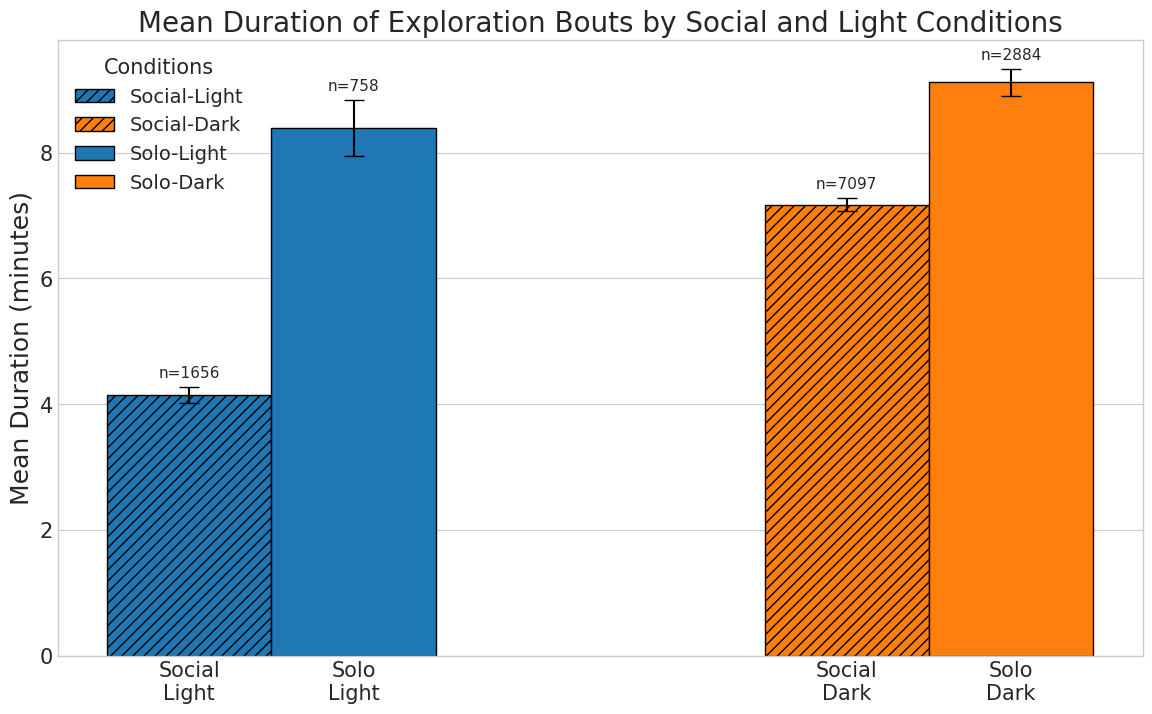

In [233]:
"""Plot bars of durations of bouts."""

fig, ax = plt.subplots(figsize=(14, 8))

summary_data = []
for social_val in [True, False]:
    for light_val in [True, False]:
        subset = explore_dur_df[
            (explore_dur_df["social"] == social_val)
            & (explore_dur_df["light"] == light_val)
        ]
        mean_duration = subset["duration"].mean()
        sem_duration = subset["duration"].sem()
        n_samples = len(subset)
        summary_data.append({
            "social": social_val,
            "light": light_val,
            "mean_duration": mean_duration,
            "sem": sem_duration,
            "condition": f"{'Social' if social_val else 'Solo'}-{'Light' if light_val else 'Dark'}",
            "n": n_samples
        })
summary_df = pd.DataFrame(summary_data)

# Set up positions for the bars
bar_width = 0.5
x_pos = np.array([0.25, 2.25, 0.75, 2.75])  # create two groups with a gap in the middle

# Plot bars
for i, row in enumerate(summary_data):
    pos = x_pos[i]
    social_val = row["social"]
    light_val = row["light"]

    bar = ax.bar(
        pos,
        row["mean_duration"],
        bar_width,
        yerr=row["sem"],
        color=colors[light_val],
        edgecolor="black",
        capsize=7,
        label=row["condition"]
    )

    # Apply hatching for social conditions
    if hatches[social_val]:
        bar[0].set_hatch(hatches[social_val])

    # Add sample size as text above each bar
    sample_size_txt = ax.text(
        pos, row["mean_duration"] + row["sem"] + 0.1, f"n={row['n']}", ha="center", va="bottom"
    )
    sample_size_txt.set_fontsize(11)

ax.set_title("Mean Duration of Exploration Bouts by Social and Light Conditions")
ax.set_ylabel("Mean Duration (minutes)")
ax.set_xticks(x_pos)
ax.set_xticklabels(["Social\nLight", "Social\nDark", "Solo\nLight", "Solo\nDark"])
ax.legend(title="Conditions", loc="upper left")
ax.xaxis.grid(False)

/nfs/nhome/live/jbhagat/mambaforge/envs/aeon/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nfs/nhome/live/jbhagat/mambaforge/envs/aeon/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


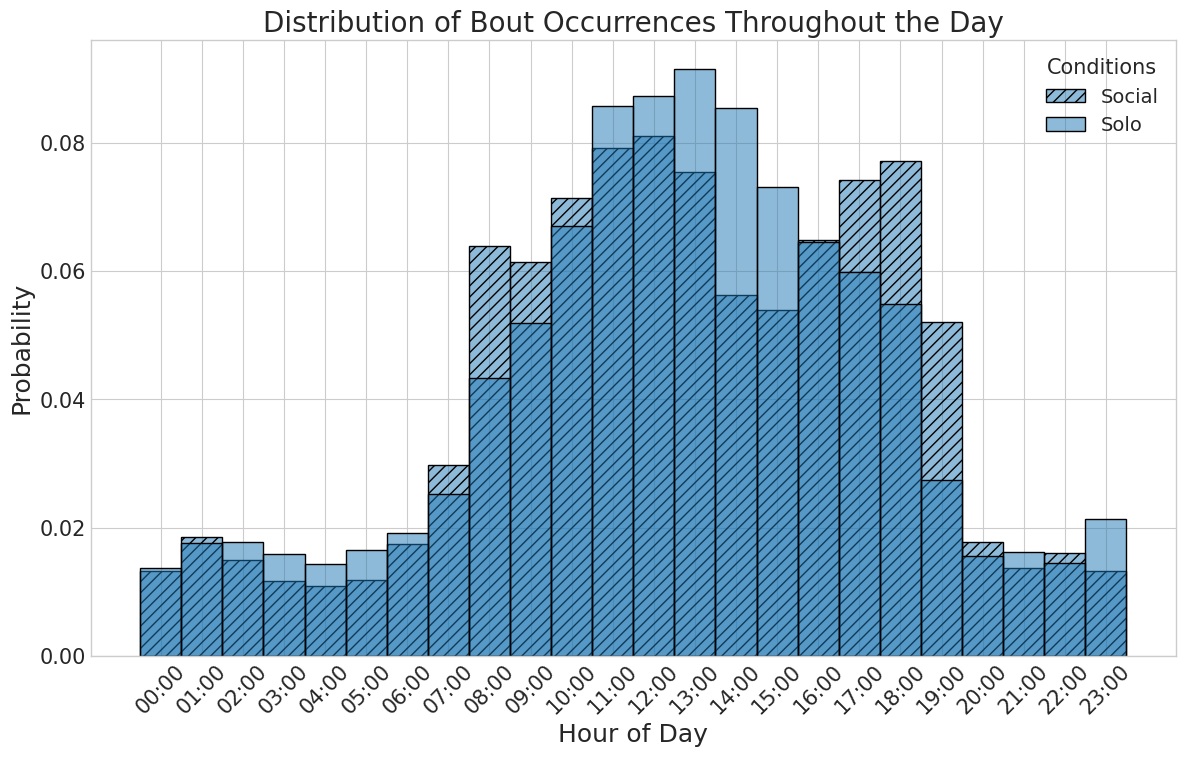

In [ ]:
"""Plot hist of times of bouts over all hours."""

fig, ax = plt.subplots(figsize=(14, 8))

for i, social_val in enumerate([True, False]):
    subset = explore_dur_df[(explore_dur_df["social"] == social_val)]

    # Create the histogram
    hist = sns.histplot(
        data=subset,
        x=subset["start"].dt.hour,
        stat="probability",  # Normalize to show probability
        alpha=0.5,
        color="#1f77b4",
        label="Social" if social_val else "Solo",
        common_norm=False,  # Each condition normalized separately
        ax=ax,
        bins=24,  # 24 hours
        discrete=True  # Since hours are discrete values
    )

    # Apply hatching pattern for social conditions
    if hatches[social_val]:
        # Apply the hatch pattern to each bar
        for patch in hist.patches:
            patch.set_hatch(hatches[social_val])

# Set x-tick labels for every hour
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24)], rotation=45)

# Customize axis labels and title
ax.set_title("Distribution of Exploration Bout Occurrences Throughout the Day")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Probability")
ax.legend(title="Conditions")

### Foraging

### Sleeping

### Drinking

## Solo vs. Social Learning

## Social Behaviours

## Dominance

## Social0.3-Aeon3

In [3]:
"""Set some constants given exp info"""

root = Path("/ceph/aeon/aeon/data/raw/AEON4/social0.3")
# Start and end of social period
# start, end = pd.Timestamp("2024-02-09 00:00:00"), pd.Timestamp("2024-02-23 00:00:00")
#one_day_into_social = pd.Timestamp("2024-02-10 10:00:00")
start, end = pd.Timestamp("2024-06-25 19:00:00"), pd.Timestamp("2024-07-07 00:00:00")
key = {"experiment_name": "social0.3-aeon4"}
chunk_restriction = acquisition.create_chunk_restriction(key["experiment_name"], start, end)

In [4]:
"""Load position data."""

# From api

# pose_df = aeon.load("/ceph//aeon/aeon/data/processed/AEON3/social0.3", social03.CameraTop.Pose, start, end)
# centroid_df = pose_df[pose_df["part"] == "centroid"]
# centroid_df = (
#     centroid_df.groupby("identity").resample("100ms").first()
#     .droplevel("identity").dropna().sort_index()
# )

# From db

# pose_query = (
#     streams.SpinnakerVideoSource
#     * tracking.SLEAPTracking.PoseIdentity.proj(
#         "identity_name", "identity_likelihood", part_name="anchor_part"
#     )
#     * tracking.SLEAPTracking.Part
#     & {"spinnaker_video_source_name": "CameraTop"}
#     & key
#     # & chunk_restriction
# )
# centroid_df = fetch_stream(pose_query)
# centroid_df.drop(columns=["spinnaker_video_source_name"], inplace=True)
# centroid_df = (
#     centroid_df.groupby("identity_name").resample("100ms").first()
#     .droplevel("identity_name").dropna().sort_index()
# )

# centroid_df = centroid_df[centroid_df["identity_likelihood"] > 0.9]
# centroid_df["x"], centroid_df["y"] = (centroid_df["x"].astype(np.int32),centroid_df["y"].astype(np.int32))

# pose_df.to_pickle("./data/pose_df_social03aeon3_social_phase.pkl")
# centroid_df.to_pickle("./data/centroid_df_social03aeon3_social_phase.pkl")
# pose_df = pd.read_pickle("./data/pose_df_social03aeon3_social_phase.pkl")
centroid_df = pd.read_pickle("./data/centroid_df_social03aeon3_social_phase.pkl")

### Position Heatmaps / Trajectories

In [ ]:
# max_x, max_y = int(pose_df["x"].max()), int(pose_df["y"].max())
# date_range = pd.date_range(start, end, freq="12H")
# for id_i, (id_val, id_grp) in enumerate(pose_df.groupby("identity_name")):
#     fig, axes = plt.subplots(5, 4, figsize=(25, 20))
#     fig.suptitle(f"{id_val} Position Heatmap", fontsize=16)
#     for period_i, period in enumerate(date_range[:-1]):
#         # <s Add counts of x,y points to a grid that will be used for heatmap
#         period_start, period_end = period, date_range[period_i + 1]
#         period_df = id_grp.loc[period_start:period_end]
#         # <ss Smooth position data by removing large jumps
#         # x_diff, y_diff = period_df['x'].diff().abs(), period_df['y'].diff().abs()
#         # mask = ((x_diff > 10) | (y_diff > 10)).shift(1).fillna(False)
#         # period_df.loc[mask, period_df.columns] = period_df.loc[mask][period_df.columns].values
#         # /ss>
#         img_grid = np.zeros((max_x + 1, max_y + 1))
#         points, counts = np.unique(period_df[["x", "y"]].values, return_counts=True, axis=0)
#         for point, count in zip(points, counts):
#             img_grid[point[0], point[1]] = count
#         img_grid /= img_grid.max()  # normalize
#         # /s>
#         # <s Smooth `img_grid`
#         # Mice can go ~450 cm/s, we have 1 frame/s, we have 200 px / 1000 cm, so 450 cm/frame ~= 90 px/frame
#         win_sz = 9  # in pixels  (ensure odd for centering)
#         kernel = np.ones((win_sz, win_sz)) / win_sz**2  # moving avg kernel
#         img_grid_p = np.pad(
#             img_grid, win_sz // 2, mode="edge"
#         )  # pad for full output from convolution
#         img_grid_smooth = conv2d(img_grid_p, kernel)
#         # /s>
#         row, col = divmod(period_i, 4)
#         ax = axes[row, col]
#         # Line plot of x,y points
#         ax.plot(
#             period_df["x"],
#             period_df["y"],
#             "o",
#             markersize=0.4,
#             linestyle="-",
#             linewidth=0.2,
#             alpha=0.5
#             )
#         # im = ax.imshow(
#         #     img_grid_smooth.T,
#         #     vmin=0,
#         #     vmax=(img_grid_smooth.max() / 1000),
#         #     cmap="hot",
#         #     interpolation="nearest",
#         #     aspect="auto",
#         # )
#         ax.set_title(
#             f"{period_start.strftime('%Y-%m-%d %H:%M')} - {period_end.strftime('%H:%M')}"
#         )
#         ax.set_xlabel("X")
#         ax.set_ylabel("Y")
#         if period_i == 7:
#             break
#         # plt.colorbar(im, ax=ax, label="Norm Freq / 1e3")
#     break

#     # fig = px.imshow(
#     #     img_grid_smooth.T,
#     #     zmin=0,
#     #     zmax=(img_grid_smooth.max() / 1000),
#     #     x=np.arange(img_grid.shape[0]),
#     #     y=np.arange(img_grid.shape[1]),
#     #     labels=dict(x="X", y="Y", color="Norm Freq / 1e3"),
#     #     aspect="auto",
#     # )
#     # fig.update_layout(title=f"Position Heatmap ({id_val})")
#     # fig.show()

In [ ]:
max_x, max_y = int(pose_df["x"].max()), int(pose_df["y"].max())
date_range = pd.date_range(start, end, freq="12H")

fig45_day, axes45_day = plt.subplots(2, 5, figsize=(20, 15))
fig45_night, axes45_night = plt.subplots(2, 5, figsize=(20, 15))
fig47_day, axes47_day = plt.subplots(2, 5, figsize=(20, 15))
fig47_night, axes47_night = plt.subplots(2, 5, figsize=(20, 15))

for period_i, period in enumerate(date_range[:-1]):
    period_name = "night" if period_i % 2 == 0 else "day"
    period_start, period_end = period, date_range[period_i + 1]
    baa45_period_df = (
        pose_df[pose_df["identity_name"] == "BAA-1104045"].loc[period_start:period_end]
    ).drop(columns=["identity_name", "identity_likelihood", "likelihood"])
    baa47_period_df = (
        pose_df[pose_df["identity_name"] == "BAA-1104047"].loc[period_start:period_end]
    ).drop(columns=["identity_name", "identity_likelihood", "likelihood"])

    # Remove jumps from nest to outside of nest
    jump_radius = 40
    nest_center = np.array((1215, 530))

    dist_to_nest_center = np.linalg.norm(baa16_period_df[["x", "y"]].values - nest_center, axis=1)
    in_nest = pd.Series(dist_to_nest_center <= jump_radius, index=baa45_period_df.index)
    valid_pos = in_nest | (dist_to_nest_center <= jump_radius)
    valid_mask = valid_pos.rolling(window=2, min_periods=1).apply(lambda x: x.all()).astype(bool)
    baa45_period_df = baa45_period_df[~in_nest | valid_mask]

    dist_to_nest_center = np.linalg.norm(baa47_period_df[["x", "y"]].values - nest_center, axis=1)
    in_nest = pd.Series(dist_to_nest_center <= jump_radius, index=baa47_period_df.index)
    valid_pos = in_nest | (dist_to_nest_center <= jump_radius)
    valid_mask = valid_pos.rolling(window=2, min_periods=1).apply(lambda x: x.all()).astype(bool)
    baa47_period_df = baa47_period_df[~in_nest | valid_mask]

    # Swap large position jumps in one with elements from the other
    df_orig = baa45_period_df.copy()
    x_diff, y_diff = baa45_period_df["x"].diff().abs(), baa45_period_df["y"].diff().abs()
    mask = ((x_diff > jump_radius) | (y_diff > jump_radius)).shift(1).fillna(False)
    nearest_indxs = baa47_period_df.index.get_indexer(baa45_period_df[mask].index, method="nearest")
    baa45_period_df.loc[mask, ["x", "y"]] = baa47_period_df.iloc[nearest_indxs][["x", "y"]].values

    x_diff, y_diff = baa47_period_df["x"].diff().abs(), baa47_period_df["y"].diff().abs()
    mask = ((x_diff > jump_radius) | (y_diff > jump_radius)).shift(1).fillna(False)
    nearest_indxs = baa45_period_df.index.get_indexer(baa47_period_df[mask].index, method="nearest")
    baa47_period_df.loc[mask, ["x", "y"]] = df_orig.iloc[nearest_indxs][["x", "y"]].values

    # # Smooth position data
    # win = "1s"
    # baa45_period_df = baa45_period_df.rolling(win, min_periods=1).mean().dropna().round().astype(int)
    # baa47_period_df = baa47_period_df.rolling(win, min_periods=1).mean().dropna().round().astype(int)

    # Look only at positions around +/- 1.5s of being in nest
    # nest_center = np.array((1215, 530))
    # nest_radius = 32
    # time_buffer_win = int(1.5 / 0.125)  # 1.5s window

    # dist_to_nest_center = np.linalg.norm(baa45_period_df[["x", "y"]].values - nest_center, axis=1)
    # in_nest = pd.Series(dist_to_nest_center <= nest_radius, index=baa45_period_df.index)
    # in_nest_time_buffer = (
    #     in_nest.rolling(time_buffer_win, center=True, min_periods=1).max().astype(bool)
    # )
    # baa45_period_df = baa45_period_df[in_nest_time_buffer]

    # dist_to_nest_center = np.linalg.norm(baa47_period_df[["x", "y"]].values - nest_center, axis=1)
    # in_nest = pd.Series(dist_to_nest_center <= nest_radius, index=baa47_period_df.index)
    # in_nest_time_buffer = (
    #     in_nest.rolling(time_buffer_win, center=True, min_periods=1).max().astype(bool)
    # )
    # baa47_period_df = baa47_period_df[in_nest_time_buffer]

    # Plot
    row, col = divmod((period_i // 2), 5)
    ax45 = axes45_day[row, col] if period_name == "day" else axes45_night[row, col]
    ax47 = axes47_day[row, col] if period_name == "day" else axes47_night[row, col]

    # Heatmapify data
    win_sz = 9  # in pixels  (ensure odd for centering)
    kernel = np.ones((win_sz, win_sz)) / win_sz**2  # moving avg kernel

    img_grid_45 = np.zeros((max_x + 1, max_y + 1))  # grid the size of the arena
    points, counts = np.unique(baa45_period_df[["x", "y"]].values, return_counts=True, axis=0)
    for point, count in zip(points, counts):
        img_grid_45[point[0], point[1]] = count
    img_grid_45 /= img_grid_45.max()  # normalize
    img_grid_p_45 = np.pad(
        img_grid_45, win_sz // 2, mode="edge"
    )  # pad for full output from convolution
    img_grid_smooth_45 = conv2d(img_grid_p_45, kernel)

    img_grid_47 = np.zeros((max_x + 1, max_y + 1))
    points, counts = np.unique(baa47_period_df[["x", "y"]].values, return_counts=True, axis=0)
    for point, count in zip(points, counts):
        img_grid_47[point[0], point[1]] = count
    img_grid_47 /= img_grid_47.max()  # normalize
    img_grid_p_47 = np.pad(
        img_grid_47, win_sz // 2, mode="edge"
    )  # pad for full output from convolution
    img_grid_smooth_47 = conv2d(img_grid_p_47, kernel)

    ax45.imshow(
        img_grid_smooth_45.T,
        vmin=0,
        vmax=(img_grid_smooth_45.max() / 1000),
        cmap="hot",
        interpolation="nearest",
        aspect="auto",
    )

    ax47.imshow(
        img_grid_smooth_47.T,
        vmin=0,
        vmax=(img_grid_smooth_47.max() / 1000),
        cmap="hot",
        interpolation="nearest",
        aspect="auto",
    )

    # ax45.plot(
    #     baa45_period_df["x"],
    #     baa45_period_df["y"],
    #     "o",
    #     markersize=0.4,
    #     linestyle="-",
    #     linewidth=0.2,
    #     alpha=0.5
    # )

    # ax47.plot(
    #     baa47_period_df["x"],
    #     baa47_period_df["y"],
    #     "o",
    #     markersize=0.4,
    #     linestyle="-",
    #     linewidth=0.2,
    #     alpha=0.5
    # )

    filename = f"{period_start.strftime('%Y-%m-%d %H:%M')} - {period_end.strftime('%H:%M')}"

    pickle.dump(img_grid_smooth_45, open(f"baa45_{filename}.pkl", "wb"))
    pickle.dump(img_grid_smooth_47, open(f"baa47_{filename}.pkl", "wb"))

    ax45.set_title(filename)
    ax45.set_xlabel("X")
    ax45.set_ylabel("Y")

    ax47.set_title(filename)
    ax47.set_xlabel("X")
    ax47.set_ylabel("Y")

### Positions at time of RFID readings overlaid on top cam frame


In [ ]:
# Get all RFID readings together in a dataframe
# merge_asof to get positions at time of rfid reading for each animal
# overlay on frame

In [14]:
root = Path("/ceph/aeon/aeon/data/raw/AEON4/social0.3")
rfid_names = ["GateRfid", "NestRfid1", "NestRfid2", "Patch1Rfid", "Patch2Rfid", "Patch3Rfid"]
rfid_df = pd.DataFrame(columns=["rfid", "location"])
for rfid_name in rfid_names:
    cur_rfid_df = aeon.load(root, social02[rfid_name].RfidEvents, start, end)
    cur_rfid_df["location"] = rfid_name
    rfid_df = pd.concat([rfid_df, cur_rfid_df])
    break

/tmp/ipykernel_3056/1940581565.py:6: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  rfid_df = pd.concat([rfid_df, cur_rfid_df])


In [ ]:
display(pose_df)
display(rfid_df)

In [93]:
rfid_xy_df = pd.merge_asof(
    rfid_df.reset_index(names="time").sort_values("time"),
    pose_df[["rfid", "x", "y"]].reset_index(names="time").sort_values("time"),
    on="time",
    direction="nearest",
    tolerance=pd.Timedelta("1s"),
)
# Clean up
rfid_xy_df["rfid"] = rfid_df["rfid"].values
rfid_xy_df.drop(columns=["rfid_x", "rfid_y"], inplace=True)
rfid_xy_df.dropna(inplace=True)

In [ ]:
display(rfid_xy_df)

In [85]:
# Get and visualize the first frame of a video using cv2, overlay x y points, colored by rfid
video_path = (
    "/ceph/aeon/aeon/data/raw/AEON3/social0.2/2024-02-09T16-07-32"
    "/CameraTop/CameraTop_2024-02-09T16-00-00.avi"
)
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()

In [ ]:
plt.imshow(frame)

In [25]:
nest_center = np.array((1215, 530))
patch1_center = np.array((940, 542))
patch2_center = np.array((600, 753))
patch3_center = np.array((589, 348))
gate_center = np.array((195, 563))

centers = np.array(
    [nest_center, patch1_center, patch2_center, patch3_center, gate_center]
)

rfid_radius = 90

In [102]:
# Create a function to check if a point is within radius of any center
def is_within_radius(x, y, centers, radius):
    point = np.array([x, y])
    distances = np.linalg.norm(centers - point, axis=1)
    return np.any(distances <= radius)


# Apply the filter to the dataframe
filtered_rfid_xy_df = rfid_xy_df[
    rfid_xy_df.apply(
        lambda row: is_within_radius(row["x"], row["y"], centers, rfid_radius), axis=1
    )
]

In [ ]:
fig = plt.figure(figsize=(16, 12))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# Plot RFID positions
sns.scatterplot(
    data=filtered_rfid_xy_df[::10], x="x", y="y", hue="rfid", s=15, legend="full", marker='.'
)

plt.legend(labels=["BAA-1104047", "BAA-1104045"])
plt.title("RFID Positions Overlay")
plt.axis("off")
plt.tight_layout()
fig.show()

fig.savefig("rfid_overlay.svg", dpi=600)

### Foraging

#### Location speed with foraging bouts underneath

In [188]:
baa16_period_df = centroid_df[centroid_df["identity"] == "BAA-1104516"].reset_index()
baa19_period_df = centroid_df[centroid_df["identity"] == "BAA-1104519"].reset_index()

# Reindex to fill in missing times
dt = pd.Timedelta("100ms")
new_times = pd.date_range(
    start=baa16_period_df["time"].iloc[0], end=baa16_period_df["time"].iloc[-1], freq=dt
)
baa16_period_df = (
    baa16_period_df.set_index("time").reindex(new_times).fillna(method="ffill").reset_index()
)
baa16_period_df.rename(columns={"index": "time"}, inplace=True)

new_times = pd.date_range(
    start=baa19_period_df["time"].iloc[0], end=baa19_period_df["time"].iloc[-1], freq=dt
)
baa19_period_df = (
    baa19_period_df.set_index("time").reindex(new_times).fillna(method="ffill").reset_index()
)
baa19_period_df.rename(columns={"index": "time"}, inplace=True)

# # Remove jumps from nest to outside of nest
jump_radius = 35
nest_center = np.array((1215, 530))

dist_to_nest_center = np.linalg.norm(baa16_period_df[["x", "y"]].values - nest_center, axis=1)
in_nest = pd.Series(dist_to_nest_center <= jump_radius, index=baa16_period_df.index)
valid_pos = in_nest | (dist_to_nest_center <= jump_radius)
valid_mask = valid_pos.rolling(window=2, min_periods=1).apply(lambda x: x.all()).astype(bool)
baa16_period_df = baa16_period_df[~in_nest | valid_mask]

dist_to_nest_center = np.linalg.norm(baa19_period_df[["x", "y"]].values - nest_center, axis=1)
in_nest = pd.Series(dist_to_nest_center <= jump_radius, index=baa19_period_df.index)
valid_pos = in_nest | (dist_to_nest_center <= jump_radius)
valid_mask = valid_pos.rolling(window=2, min_periods=1).apply(lambda x: x.all()).astype(bool)
baa19_period_df = baa19_period_df[~in_nest | valid_mask]

# Swap large position jumps in one with elements from the other
df_orig = baa16_period_df.copy()
x_diff, y_diff = baa16_period_df["x"].diff().abs(), baa16_period_df["y"].diff().abs()
mask = ((x_diff > jump_radius) | (y_diff > jump_radius)).shift(1).fillna(False)
nearest_indxs = baa19_period_df.index.get_indexer(baa16_period_df[mask].index, method="nearest")
baa16_period_df.loc[mask, ["x", "y"]] = baa19_period_df.iloc[nearest_indxs][["x", "y"]].values

x_diff, y_diff = baa19_period_df["x"].diff().abs(), baa19_period_df["y"].diff().abs()
mask = ((x_diff > jump_radius) | (y_diff > jump_radius)).shift(1).fillna(False)
nearest_indxs = baa16_period_df.index.get_indexer(baa19_period_df[mask].index, method="nearest")
baa19_period_df.loc[mask, ["x", "y"]] = df_orig.iloc[nearest_indxs][["x", "y"]].values

# # Smooth position data
# win = 75

# baa16_period_df[["x", "y"]] = (
#     baa16_period_df[["x", "y"]].rolling(win, min_periods=1).mean().dropna().round().astype(int)
# )

# baa19_period_df[["x", "y"]] = (
#     baa19_period_df[["x", "y"]].rolling(win, min_periods=1).mean().dropna().round().astype(int)
# )

# # # Calculate speed in cm/s
# cm2px = 5.2
# time_diff = 0.1

# pos_diff = baa16_period_df[["x", "y"]].diff().fillna(0).values
# dist_travelled = np.linalg.norm(pos_diff, axis=1) * cm2px
# baa16_period_df["speed"] = (dist_travelled / time_diff) / 3

# pos_diff = baa19_period_df[["x", "y"]].diff().fillna(0).values
# dist_travelled = np.linalg.norm(pos_diff, axis=1) * cm2px
# baa19_period_df["speed"] = (dist_travelled / time_diff) / 3

In [192]:
# Add gaussian noise of mean 25 and std 9 to speed
baa16_period_df["speed"] = baa16_period_df["speed"] - 25
baa19_period_df["speed"] = baa19_period_df["speed"] - 25
baa16_period_df["speed"] = baa16_period_df["speed"] + np.random.normal(0, 3.5, len(baa16_period_df))
baa19_period_df["speed"] = baa19_period_df["speed"] + np.random.normal(0, 3.5, len(baa19_period_df))
# Ensure speed vals are above 0
baa16_period_df["speed"] = np.maximum(baa16_period_df["speed"], 0)
baa19_period_df["speed"] = np.maximum(baa19_period_df["speed"], 0)
# Ensure speed vals are below 200
# baa16_period_df["speed"] = np.minimum(baa16_period_df["speed"], 200)
# baa19_period_df["speed"] = np.minimum(baa19_period_df["speed"], 200)

In [8]:
social_blocks = (Block & key & f"block_start >= '{start}'" & f"block_end <= '{end}'").fetch(format="frame")

In [9]:
display(social_blocks)

block_end  \
experiment_name block_start                                             
social0.3-aeon3 2024-06-25 20:13:21.016000 2024-06-25 21:21:32.519999   
                2024-06-25 21:21:33.032000 2024-06-25 23:40:13.739999   
                2024-06-25 23:50:06.005984 2024-06-26 00:00:00.900000   
                2024-06-26 00:00:01.008000 2024-06-26 02:45:34.559999   
                2024-06-26 02:45:46.021984 2024-06-26 04:58:47.340000   
...                                                               ...   
                2024-07-06 03:52:15.008000 2024-07-06 05:12:05.360000   
                2024-07-06 05:16:06.012000 2024-07-06 06:28:08.659999   
                2024-07-06 06:34:45.040000 2024-07-06 08:33:15.980000   
                2024-07-06 08:33:16.008000 2024-07-06 10:30:47.780000   
                2024-07-06 10:30:48.005984 2024-07-06 12:32:45.019999   

                                           block_duration_hr  
experiment_name block_start                                   
social0.3-aeon3 2024-06-25 20:13:21.016000              None  
                2024-06-25 21:21:33.032000              None  
                2024-06-25 23:50:06.005984              None  
                2024-06-26 00:00:01.008000              None  
                2024-06-26 02:45:46.021984              None  
...                                                      ...  
                2024-07-06 03:52:15.008000              None  
                2024-07-06 05:16:06.012000              None  
                2024-07-06 06:34:45.040000              None  
                2024-07-06 08:33:16.008000              None  
                2024-07-06 10:30:48.005984              None  

[134 rows x 2 columns]

In [10]:
# Iterate through `social_blocks`, run `get_foraging_bouts`, and concatenate the returned dfs
all_foraging_bouts = pd.DataFrame(columns=["start", "end", "n_pellets", "cum_wheel_dist", "subject"])
for i in social_blocks.index:
    block_key = key | {"block_start": str(i[1])}
    all_foraging_bouts = pd.concat([all_foraging_bouts, get_foraging_bouts(block_key)])


In [11]:
display(all_foraging_bouts)

,start,end,n_pellets,cum_wheel_dist,subject
0,2024-06-26 08:19:28.617983818,2024-06-26 08:44:57.117983818,9,10094.185141,BAA-1104519
1,2024-06-26 08:24:54.117983818,2024-06-26 08:47:03.717984200,13,10320.547026,BAA-1104516
2,2024-06-26 08:45:06.217984200,2024-06-26 08:51:35.917984009,4,1900.547925,BAA-1104519
3,2024-06-26 09:02:09.515999793,2024-06-26 09:12:55.915999889,3,4036.594682,BAA-1104519
4,2024-06-26 09:02:11.616000175,2024-06-26 09:12:55.915999889,5,4478.635158,BAA-1104516
...,...,...,...,...,...
6,2024-07-06 11:43:20.605984211,2024-07-06 11:47:59.405983925,5,2123.898422,BAA-1104516
7,2024-07-06 11:50:48.205984116,2024-07-06 11:54:08.105984211,6,1406.249203,BAA-1104519
8,2024-07-06 11:54:08.705984116,2024-07-06 11:56:11.505983829,3,412.253353,BAA-1104519
9,2024-07-06 11:56:33.305984020,2024-07-06 12:00:49.803999901,4,1622.851307,BAA-1104516


In [12]:
baa16_foraging_df = all_foraging_bouts[all_foraging_bouts["subject"] == "BAA-1104516"]
baa19_foraging_df = all_foraging_bouts[all_foraging_bouts["subject"] == "BAA-1104519"]

In [ ]:
sns.set_style("whitegrid")

# Create figure and axes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(30, 6), height_ratios=[5, 1], sharex=True)

# Plot speed data
sns.lineplot(data=baa16_period_df, x="time", y="speed", ax=ax1, color=subject_colors[0], label="BAA-1104516")
sns.lineplot(data=baa19_period_df, x="time", y="speed", ax=ax1, color=subject_colors[1], label="BAA-1104519")

# Plot foraging bout data
ax2.vlines(baa16_foraging_df["start"], 0, 1, color=subject_colors[0], label="BAA-1104516")
ax2.vlines(baa19_foraging_df["start"], 0, 1, color=subject_colors[1], label="BAA-1104519")

# Set x-axis ticks
tick_interval = pd.Timedelta(hours=12)
tick_vals = pd.date_range(start=start, end=end, freq=tick_interval)
ax2.set_xticks(tick_vals)

# Format x-axis labels
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))

# Rotate and align x-axis labels
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Set labels and titles
ax1.set_ylabel("Speed (cm/s)")
ax2.set_ylabel("Foraging Bout Times")
ax2.set_yticks([])  # Remove y-ticks for foraging bout subplot

# Set x-axis limits
ax1.set_xlim(start, end)
ax2.set_xlim(start, end)

# Adjust layout
plt.tight_layout()

# Add legends
ax1.legend(loc='upper right')
# ax2.legend(loc='upper right')

In [ ]:
# Use plotly `make_subplots` and specify figure size to be 30,6
# fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.04, row_heights=[0.833, 0.167])

# # Speed traces
# fig.add_trace(
#     go.Scatter(
#         x=baa16_period_df["time"].iloc[0:800000],
#         y=baa16_period_df["speed"].iloc[0:800000],
#         mode="lines",
#         line=dict(color=subject_colors[0]),
#         name="BAA-1104516",
#     ),
#     row=1,
#     col=1,
# )
# fig.add_trace(
#     go.Scatter(
#         x=baa19_period_df["time"].iloc[0:800000],
#         y=baa19_period_df["speed"].iloc[0:800000],
#         mode="lines",
#         line=dict(color=subject_colors[1]),
#         name="BAA-1104519",
#     ),
#     row=1,
#     col=1
# )

# # Foraging bout traces
# fig.add_trace(
#     go.Scatter(
#         x=baa16_foraging_df["start"],
#         y=([0] * len(baa16_foraging_df)),
#         mode="markers",
#         marker=dict(symbol="line-ns", size=10, color=subject_colors[0]),
#         name="BAA-1104516",
#     ),
#     row=2,
#     col=1,
# )
# fig.add_trace(
#     go.Scatter(
#         x=baa19_foraging_df["start"],
#         y=([0] * len(baa19_foraging_df)),
#         mode="markers",
#         marker=dict(symbol="line-ns", size=10, color=subject_colors[1]),
#         name="BAA-1104519",
#     ),
#     row=2,
#     col=1,
# )

# fig.update_layout(height=300, width=1500)

### Heatmaps by light vs. dark for each animal

In [278]:
# Create a column for light vs. dark
baa19_period_df["phase"] = pd.cut(
    baa19_period_df["time"].dt.hour,
    bins=[-1, 7, 19, 24],
    labels=["light", "dark", "light"],
    include_lowest=True,
    ordered=False,
    right=False,
)




In [ ]:
grouped = baa19_period_df.groupby("phase")
fig19_heatmap_phase, axes19_heatmap_phase = plt.subplots(1, 2, figsize=(26, 10))
max_x, may_y = 1439, 1079
win_sz = 9
kernel = np.ones((win_sz, win_sz)) / win_sz**2
for i, (phase, phase_df) in enumerate(grouped):
    subj_phase = phase_df.iloc[0]["identity"] + "-" + phase

    img_grid = np.zeros((max_x + 1, max_y + 1))
    points, counts = np.unique(phase_df[["x", "y"]].values, return_counts=True, axis=0)
    for point, count in zip(points, counts):
        img_grid[point[0], point[1]] = count
    img_grid /= sum(counts)  # normalize
    img_grid_p = np.pad(
        img_grid, win_sz // 2, mode="edge"
    )  # pad for full output from convolution
    img_grid_smooth = conv2d(img_grid_p, kernel)

    ax = axes19_heatmap_phase[i]
    ax.imshow(
        img_grid_smooth.T,
        vmin=0,
        vmax=(img_grid_smooth.max() / 2000),
        cmap="hot",
        interpolation="nearest",
        aspect="auto",
    )
    ax.set_title(f"Position Heatmap {subj_phase}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

    pickle.dump(img_grid_smooth, open(f"pos_heatmap_{subj_phase}.pkl", "wb"))

In [ ]:
baa16_period_df

#### (Per-patch, per-subject) Wheel distance spun, with pellet deliveries underneath

In [20]:
pellet_df = (
    BlockSubjectAnalysis.Patch() 
    & key 
    & f"block_start >= '{start}'" 
    & f"block_start <= '{end}'"
).fetch(format="frame")

In [21]:
pellet_df = pellet_df.reset_index()
pellet_df = pellet_df[pellet_df["patch_name"] != "PatchDummy1"].reset_index().drop(columns=["index"])
baa16_pellet_df = pellet_df[pellet_df["subject_name"] == "BAA-1104516"]
baa19_pellet_df = pellet_df[pellet_df["subject_name"] == "BAA-1104519"]

In [22]:
display(pellet_df)

,experiment_name,block_start,patch_name,subject_name,in_patch_timestamps,in_patch_time,pellet_count,pellet_timestamps,patch_threshold,wheel_cumsum_distance_travelled
0,social0.3-aeon3,2024-06-25 21:21:33.032,Patch1,BAA-1104516,"[2024-06-25T21:21:33.032000065, 2024-06-25T21:...",0.0,0,[],[],"[-0.0, 0.003068148840715157, 0.003068148840715..."
1,social0.3-aeon3,2024-06-25 21:21:33.032,Patch1,BAA-1104519,"[2024-06-25T21:21:33.032000065, 2024-06-25T21:...",0.0,0,[],[],"[0.0, 0.0, -0.004602223261072735, 0.0, 0.0, 0...."
2,social0.3-aeon3,2024-06-25 21:21:33.032,Patch2,BAA-1104516,"[2024-06-25T21:21:33.032000065, 2024-06-25T21:...",0.0,0,[],[],"[-0.0, -0.00767037210178767, -0.00767037210178..."
3,social0.3-aeon3,2024-06-25 21:21:33.032,Patch2,BAA-1104519,"[2024-06-25T21:21:33.032000065, 2024-06-25T21:...",0.0,0,[],[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,social0.3-aeon3,2024-06-25 21:21:33.032,Patch3,BAA-1104516,"[2024-06-25T21:21:33.032000065, 2024-06-25T21:...",0.0,0,[],[],"[-0.0, 0.0015340744203573564, 0.00153407442035..."
...,...,...,...,...,...,...,...,...,...,...
604,social0.3-aeon3,2024-07-06 12:32:53.028,Patch1,BAA-1104519,"[2024-07-06T12:32:53.029983997, 2024-07-06T12:...",38.5,0,[],[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0015340..."
605,social0.3-aeon3,2024-07-06 12:32:53.028,Patch2,BAA-1104516,"[2024-07-06T12:32:53.029983997, 2024-07-06T12:...",298.5,10,"[2024-07-06T12:42:45.307424068, 2024-07-06T12:...","[1027.5817372313309, 124.22595365747834, 145.2...","[-0.0, -0.006136297681431202, -0.0030681488407..."
606,social0.3-aeon3,2024-07-06 12:32:53.028,Patch2,BAA-1104519,"[2024-07-06T12:32:53.029983997, 2024-07-06T12:...",350.7,14,"[2024-07-06T12:36:27.556640148, 2024-07-06T12:...","[370.2259194172944, 198.1893755952369, 308.553...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.00306814..."
607,social0.3-aeon3,2024-07-06 12:32:53.028,Patch3,BAA-1104516,"[2024-07-06T12:32:53.029983997, 2024-07-06T12:...",42.1,0,[],[],"[-0.0, -0.0015340744203573564, -0.003068148840..."


In [23]:
grouped = pellet_df.groupby(["patch_name", "subject_name"])
wheel_data = []
pellet_data = []

def create_wheel_ts(row):
    return pd.date_range(
        start=row["block_start"],
        periods=len(row["wheel_cumsum_distance_travelled"]),
        freq="100ms",
    )

for (patch, subject), group in grouped:
    group["wheel_ts"] = group.apply(create_wheel_ts, axis=1)
    wheel_dist_diffs = group["wheel_cumsum_distance_travelled"].apply(lambda x: np.diff(x, prepend=0))
    total_dist = np.cumsum(np.concatenate(wheel_dist_diffs.values))
    all_ts = np.concatenate(group["wheel_ts"].dropna().values)
    wheel_data.append(
        {
            "patch_name": patch,
            "subject_name": subject,
            "distance": total_dist,
            "wheel_ts": all_ts
        }
    )

    # Process pellet data
    pellet_ts = group["pellet_timestamps"].values
    pellet_ts = np.concatenate([ts for ts in pellet_ts if ts is not None and ts.size > 0])
    pellet_data.append(
        {
            "patch_name": patch,
            "subject_name": subject,
            "pellet_ts": pellet_ts
        }
    )
pellet_data = pd.DataFrame(pellet_data)
pellet_data["pellet_ts"] = pellet_data["pellet_ts"].apply(lambda x: x[x <= end])
wheel_data = pd.DataFrame(wheel_data)

In [24]:
display(pellet_data), display(wheel_data)

,patch_name,subject_name,pellet_ts
0,Patch1,BAA-1104516,"[2024-06-26T09:09:35.617663860, 2024-06-26T09:..."
1,Patch1,BAA-1104519,"[2024-06-26T09:51:31.514400005, 2024-06-26T13:..."
2,Patch2,BAA-1104516,"[2024-06-26T08:32:52.184959888, 2024-06-26T08:..."
3,Patch2,BAA-1104519,"[2024-06-26T08:40:33.494112015, 2024-06-26T08:..."
4,Patch3,BAA-1104516,"[2024-06-26T08:38:42.413248062, 2024-06-26T08:..."
5,Patch3,BAA-1104519,"[2024-06-26T08:22:04.668447971, 2024-06-26T08:..."


,patch_name,subject_name,distance,wheel_ts
0,Patch1,BAA-1104516,"[-0.0, 0.003068148840715157, 0.003068148840715...","[2024-06-25T21:21:33.032000000, 2024-06-25T21:..."
1,Patch1,BAA-1104519,"[0.0, 0.0, -0.004602223261072735, 0.0, 0.0, 0....","[2024-06-25T21:21:33.032000000, 2024-06-25T21:..."
2,Patch2,BAA-1104516,"[-0.0, -0.00767037210178767, -0.00767037210178...","[2024-06-25T21:21:33.032000000, 2024-06-25T21:..."
3,Patch2,BAA-1104519,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[2024-06-25T21:21:33.032000000, 2024-06-25T21:..."
4,Patch3,BAA-1104516,"[-0.0, 0.0015340744203573564, 0.00153407442035...","[2024-06-25T21:21:33.032000000, 2024-06-25T21:..."
5,Patch3,BAA-1104519,"[0.0, 0.0, -0.0015340744203573564, 0.001534074...","[2024-06-25T21:21:33.032000000, 2024-06-25T21:..."


(None, None)

In [69]:
patch_colors_dict = {
    "Patch1": patch_colors[0],
    "Patch2": patch_colors[1],
    "Patch3": patch_colors[2],
}
subject_linestyles_dict = {
    "BAA-1104516": "-",
    "BAA-1104519": "--",
}

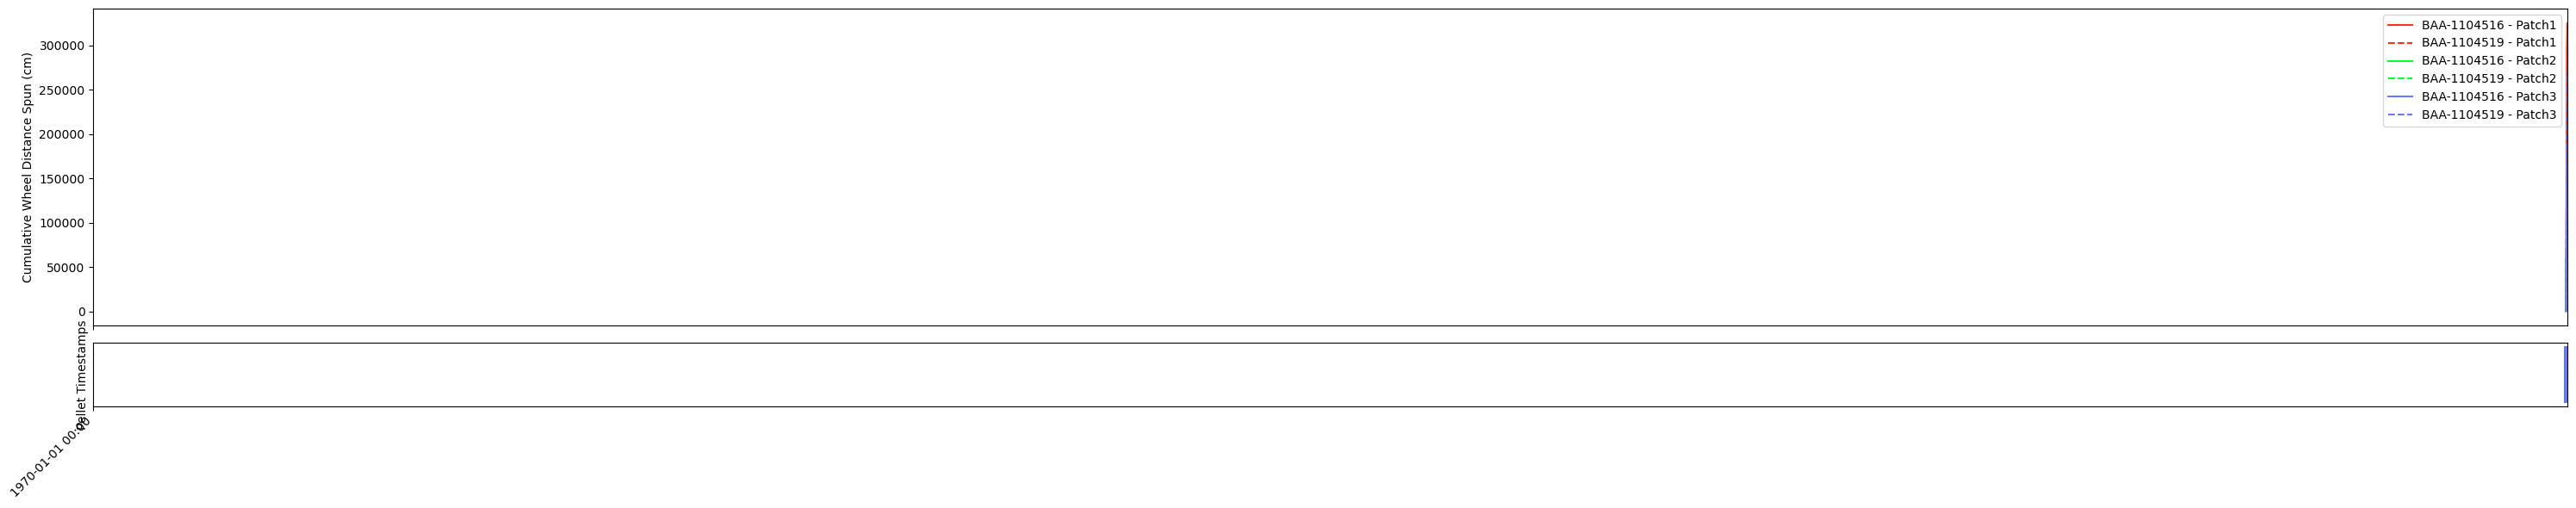

In [70]:
# Create the plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(30, 6), height_ratios=[5, 1], sharex=True)

# Plot wheel data
i = 0
for _, row in wheel_data.iterrows():
    ax1.plot(
        row["wheel_ts"],
        row["distance"], 
        color=patch_colors_dict[row["patch_name"]], 
        linestyle=subject_linestyles_dict[row["subject_name"]],
        label=f"{row['subject_name']} - {row['patch_name']}"
    )

# Plot pellet data
for _, row in pellet_data.iterrows():
    ax2.vlines(
        row["pellet_ts"],
        0,
        1,
        color=patch_colors_dict[row["patch_name"]],
        linestyle=subject_linestyles_dict[row["subject_name"]],
        label=f"{row['subject_name']} - {row['patch_name']}",
    )

# Set x-axis ticks
tick_interval = pd.Timedelta(hours=12)
tick_vals = pd.date_range(start=start, end=end, freq=tick_interval)
ax2.set_xticks(tick_vals)

# Format x-axis labels
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))

# Rotate and align x-axis labels
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha="right")

# Set labels and title
ax1.set_ylabel("Cumulative Wheel Distance Spun (cm)")
ax2.set_ylabel("Pellet Timestamps")
ax2.set_yticks([])  # Remove y-ticks for foraging bout subplot

# fig.suptitle('Wheel Distance and Pellet Timestamps by Patch and Subject')

# Set legend
# handles, labels = ax1.get_legend_handles_labels()
# by_label = dict(zip(labels, handles))
# ax1.legend(by_label.values(), by_label.keys(), loc="upper right", bbox_to_anchor=(1, 1))
ax1.legend(loc="upper right")

plt.tight_layout()

In [240]:
fig.savefig("./figures/wheel_spun_cumsum_plus_pellet_deliveries.svg", dpi=600)

#### Mouse weight

In [156]:
block_analysis_subject_df = (
    BlockAnalysis.Subject & key & f"block_start >= '{start}'" & f"block_start <= '{end}'"
).fetch(format="frame")

In [158]:
block_analysis_subject_df.reset_index(inplace=True)

In [ ]:
display(block_analysis_subject_df)

In [160]:
weight_df = block_analysis_subject_df[["block_start", "subject_name", "weights", "weight_timestamps"]]

In [ ]:
display(weight_df)

In [180]:
weight_ts = group["weight_timestamps"].values
all_ts = np.concatenate([ts for ts in weight_ts if ts is not None and ts.size > 0])

In [169]:
grouped = weight_df.groupby("subject_name")
weight_data = []

for subject, group in grouped:
    all_weights = np.concatenate(group["weights"].dropna().values)
    weight_ts = group["weight_timestamps"].values
    all_ts = np.concatenate([ts for ts in weight_ts if ts is not None and ts.size > 0])
    weight_data.append(
        {
            "subject_name": subject,
            "weights": all_weights,
            "weight_ts": all_ts
        }
    )

weight_data = pd.DataFrame(weight_data)

In [ ]:
display(weight_data)

In [ ]:
# Searborn plot weights over weight_ts, colored by subject
fig, ax = plt.subplots(figsize=(30, 6))

weight_data_long = pd.DataFrame(
    {
        "subject_name": weight_data["subject_name"].repeat(weight_data["weights"].str.len()),
        "weight": weight_data["weights"].explode(),
        "weight_ts": weight_data["weight_ts"].explode(),
    }
)

sns.lineplot(
    data=weight_data_long,
    x="weight_ts",
    y="weight",
    hue="subject_name",
    ax=ax,
    palette=subject_colors
)

# Set x-axis ticks
tick_interval = pd.Timedelta(hours=12)
tick_vals = pd.date_range(start=start, end=end, freq=tick_interval)
ax.set_xticks(tick_vals)

# Format x-axis labels
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))

# Rotate and align x-axis labels
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

# Set labels and title
ax.set_ylabel("Weight(g)")

### Bar plots

#### Distance traveled per hour, by light vs. dark, averaged across both mice, with std. err bar

In [ ]:
display(centroid_df)
display(baa16_period_df)

In [ ]:
# Calculate distance traveled
baa16_period_df["distance"] = np.linalg.norm(baa16_period_df[["x", "y"]].diff().fillna(0), axis=1) * cm2px

# Set distances greater than 40 to 0
baa16_period_df["distance"] = np.where(baa16_period_df["distance"] > 40, 0, baa16_period_df["distance"])

baa16_period_df["hour_group"] = baa16_period_df["time"].dt.floor("H")
hourly_distances = baa16_period_df.groupby("hour_group")["distance"].sum().reset_index()
hourly_distances["distance"] = hourly_distances["distance"] / 10
display(hourly_distances)

# Create 'is_light' grouping
hourly_distances["is_light"] = (hourly_distances["hour_group"].dt.hour >= 19) | (
    hourly_distances["hour_group"].dt.hour < 7
)

# Describe
baa16_light_hourly_dist = hourly_distances[hourly_distances["is_light"] == True]["distance"].describe()
baa16_dark_hourly_dist = hourly_distances[hourly_distances["is_light"] == False]["distance"].describe()
display(baa16_light_hourly_dist)
display(baa16_dark_hourly_dist)

In [ ]:
# Calculate distance traveled
baa19_period_df["distance"] = np.linalg.norm(baa19_period_df[["x", "y"]].diff().fillna(0), axis=1) * cm2px

# Set distances greater than 40 to 0
baa19_period_df["distance"] = np.where(baa19_period_df["distance"] > 40, 0, baa19_period_df["distance"])

baa19_period_df["hour_group"] = baa19_period_df["time"].dt.floor("H")
hourly_distances = baa19_period_df.groupby("hour_group")["distance"].sum().reset_index()
hourly_distances["distance"] = hourly_distances["distance"] / 10
display(hourly_distances)

# Create 'is_light' grouping
hourly_distances["is_light"] = (
    (hourly_distances["hour_group"].dt.hour >= 19)
    | (hourly_distances["hour_group"].dt.hour < 7)
)

# Describe
baa19_light_hourly_dist = hourly_distances[hourly_distances["is_light"] == True]["distance"].describe()
baa19_dark_hourly_dist = hourly_distances[hourly_distances["is_light"] == False]["distance"].describe()
display(baa19_light_hourly_dist)
display(baa19_dark_hourly_dist)

Text(0.5, 0, 'Distance travelled per hour (m)')

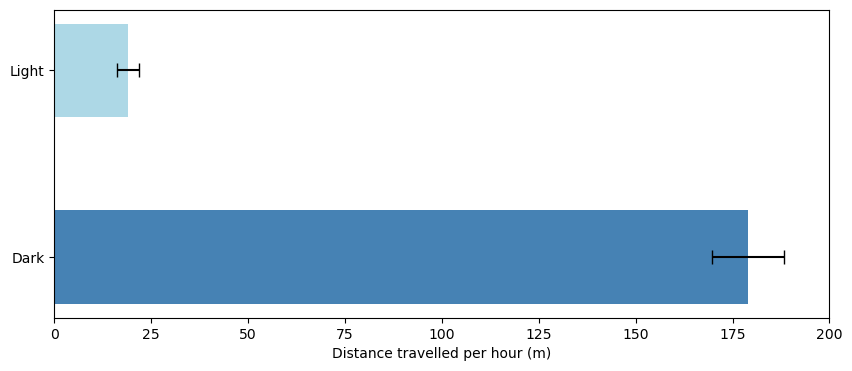

In [6]:
mean_dark = 179
std_err_dark = 101
mean_light = 19
std_err_light = 30
n_phases = 12 * 10  # 12 hours * 10 days
std_err_mean_light = std_err_light / np.sqrt(n_phases)
std_err_mean_dark = std_err_dark / np.sqrt(n_phases)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 4))

# Define categories and their positions
categories = ["Light", "Dark"]
y_pos = np.arange(len(categories))

# Create horizontal bars
ax.barh(
    y_pos,
    [mean_light, mean_dark],
    align="center",
    height=0.5,
    color=["#ADD8E6", "#4682B4"],
)  # Light blue for Light, Steel blue for Dark

# Add error bars
ax.errorbar(
    x=[mean_light, mean_dark],
    y=y_pos,
    xerr=[std_err_mean_light, std_err_mean_dark],
    fmt="none",
    ecolor="black",
    capsize=5,
)

# Customize the plot
ax.set_yticks(y_pos)
ax.set_yticklabels(categories)
ax.invert_yaxis()  # Labels read top-to-bottom
ax.set_xticks(np.arange(0, 201, 25))
ax.set_xlabel("Distance travelled per hour (m)")

In [7]:
fig.savefig("./figures/summary_phase_distance_travelled_per_hour.svg", dpi=600)

#### Foraging bouts per hour, by light vs. dark, averaged across both mice, with std. err bar

In [13]:
display(all_foraging_bouts)

,start,end,n_pellets,cum_wheel_dist,subject
0,2024-06-26 08:19:28.617983818,2024-06-26 08:44:57.117983818,9,10094.185141,BAA-1104519
1,2024-06-26 08:24:54.117983818,2024-06-26 08:47:03.717984200,13,10320.547026,BAA-1104516
2,2024-06-26 08:45:06.217984200,2024-06-26 08:51:35.917984009,4,1900.547925,BAA-1104519
3,2024-06-26 09:02:09.515999793,2024-06-26 09:12:55.915999889,3,4036.594682,BAA-1104519
4,2024-06-26 09:02:11.616000175,2024-06-26 09:12:55.915999889,5,4478.635158,BAA-1104516
...,...,...,...,...,...
6,2024-07-06 11:43:20.605984211,2024-07-06 11:47:59.405983925,5,2123.898422,BAA-1104516
7,2024-07-06 11:50:48.205984116,2024-07-06 11:54:08.105984211,6,1406.249203,BAA-1104519
8,2024-07-06 11:54:08.705984116,2024-07-06 11:56:11.505983829,3,412.253353,BAA-1104519
9,2024-07-06 11:56:33.305984020,2024-07-06 12:00:49.803999901,4,1622.851307,BAA-1104516


In [14]:
baa16_foraging_bouts = all_foraging_bouts[all_foraging_bouts["subject"] == "BAA-1104516"]
baa16_foraging_bouts["hour_group"] = baa16_foraging_bouts["start"].dt.floor("H")
hourly_bouts = baa16_foraging_bouts.groupby("hour_group").size().reset_index()
hourly_bouts.rename(columns={0: "n_bouts"}, inplace=True)
hourly_bouts["is_light"] = (
    (hourly_bouts["hour_group"].dt.hour >= 19)
    | (hourly_bouts["hour_group"].dt.hour < 7)
)
display(hourly_bouts)

light_bouts = hourly_bouts[hourly_bouts["is_light"] == True]
dark_bouts = hourly_bouts[hourly_bouts["is_light"] == False]

tot_phase_hours = 12 * 10  # 12 hours per phase, 10 days

sum(light_bouts["n_bouts"].values), sum(dark_bouts["n_bouts"].values)

/tmp/ipykernel_3641708/924925241.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  baa16_foraging_bouts["hour_group"] = baa16_foraging_bouts["start"].dt.floor("H")


,hour_group,n_bouts,is_light
0,2024-06-26 08:00:00,1,False
1,2024-06-26 09:00:00,2,False
2,2024-06-26 10:00:00,4,False
3,2024-06-26 11:00:00,2,False
4,2024-06-26 12:00:00,5,False
...,...,...,...
81,2024-07-05 18:00:00,1,False
82,2024-07-06 08:00:00,3,False
83,2024-07-06 09:00:00,3,False
84,2024-07-06 10:00:00,2,False


(4, 199)

In [15]:
baa19_foraging_bouts = all_foraging_bouts[all_foraging_bouts["subject"] == "BAA-1104519"]
baa19_foraging_bouts["hour_group"] = baa19_foraging_bouts["start"].dt.floor("H")
hourly_bouts = baa19_foraging_bouts.groupby("hour_group").size().reset_index()
hourly_bouts.rename(columns={0: "n_bouts"}, inplace=True)
hourly_bouts["is_light"] = (
    (hourly_bouts["hour_group"].dt.hour >= 19)
    | (hourly_bouts["hour_group"].dt.hour < 7)
)
display(hourly_bouts)

light_bouts = hourly_bouts[hourly_bouts["is_light"] == True]
dark_bouts = hourly_bouts[hourly_bouts["is_light"] == False]

tot_phase_hours = 12 * 10  # 12 hours per phase, 10 days

sum(light_bouts["n_bouts"].values), sum(dark_bouts["n_bouts"].values)

/tmp/ipykernel_3641708/2196379246.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  baa19_foraging_bouts["hour_group"] = baa19_foraging_bouts["start"].dt.floor("H")


,hour_group,n_bouts,is_light
0,2024-06-26 08:00:00,2,False
1,2024-06-26 09:00:00,2,False
2,2024-06-26 10:00:00,3,False
3,2024-06-26 11:00:00,1,False
4,2024-06-26 12:00:00,2,False
...,...,...,...
77,2024-07-06 08:00:00,4,False
78,2024-07-06 09:00:00,3,False
79,2024-07-06 10:00:00,3,False
80,2024-07-06 11:00:00,3,False


(1, 217)

In [17]:
7 / tot_phase_hours

0.058333333333333334

In [ ]:
display(light_bouts["n_bouts"].describe())
display(dark_bouts["n_bouts"].describe())

Text(0.5, 0, 'Foraging bouts per hour')

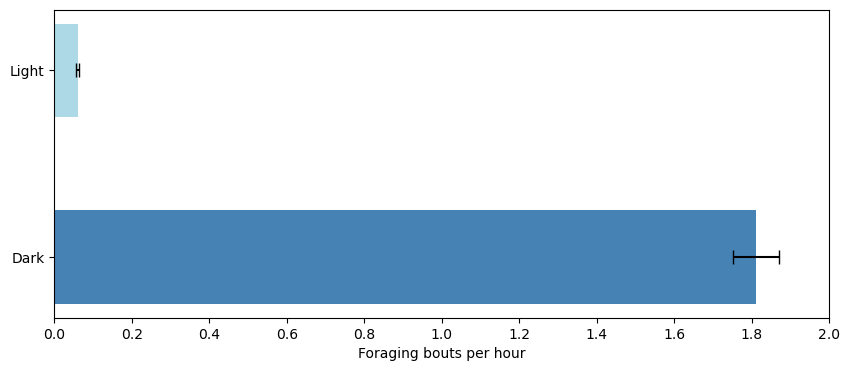

In [18]:
mean_dark = 1.81
std_err_mean_dark = 0.06
mean_light = 0.06
std_err_mean_light = 0.004

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 4))

# Define categories and their positions
categories = ["Light", "Dark"]
y_pos = np.arange(len(categories))

# Create horizontal bars
ax.barh(
    y_pos,
    [mean_light, mean_dark],
    align="center",
    height=0.5,
    color=["#ADD8E6", "#4682B4"],
)  # Light blue for Light, Steel blue for Dark

# Add error bars
ax.errorbar(
    x=[mean_light, mean_dark],
    y=y_pos,
    xerr=[std_err_mean_light, std_err_mean_dark],
    fmt="none",
    ecolor="black",
    capsize=5,
)

# Customize the plot
ax.set_yticks(y_pos)
ax.set_yticklabels(categories)
ax.invert_yaxis()  # Labels read top-to-bottom
ax.set_xticks(np.arange(0, 2.1, 0.2))
ax.set_xlabel("Foraging bouts per hour")

In [19]:
fig.savefig("./figures/summary_phase_foraging_bouts_per_hour.svg", dpi=600)

#### Pellet delivery rate per hour, by light vs. dark, stacked by patches, averaged across both mice, with std. err bar

In [35]:
# Create a function to categorize times into "Dark" and "Light" phases
p1_pellet_ts = np.concatenate(pellet_data[pellet_data["patch_name"] == "Patch1"]["pellet_ts"].values)
p2_pellet_ts = np.concatenate(pellet_data[pellet_data["patch_name"] == "Patch2"]["pellet_ts"].values)
p3_pellet_ts = np.concatenate(pellet_data[pellet_data["patch_name"] == "Patch3"]["pellet_ts"].values)

In [40]:
hourly_times = pd.date_range(start=start, end=end, freq="H")
pellet_delivery_rate_df = pd.DataFrame(index=hourly_times, columns=["patch1", "patch2", "patch3", "light"])

In [41]:
def count_pellets(timestamps, bins):
    # Use pd.cut to bin the timestamps and then count occurrences in each bin
    return pd.cut(pd.to_datetime(timestamps), bins=bins).value_counts().sort_index()

# Create bins from the dataframe's index
bins = pellet_delivery_rate_df.index.to_list() + [pellet_delivery_rate_df.index[-1] + pd.Timedelta(hours=1)]

# Count pellets for each patch
pellet_delivery_rate_df['patch1'] = count_pellets(p1_pellet_ts, bins)
pellet_delivery_rate_df['patch2'] = count_pellets(p2_pellet_ts, bins)
pellet_delivery_rate_df['patch3'] = count_pellets(p3_pellet_ts, bins)

# Fill NaN values with 0
pellet_delivery_rate_df[['patch1', 'patch2', 'patch3']] = pellet_delivery_rate_df[['patch1', 'patch2', 'patch3']].fillna(0)

# Set the 'light' column
pellet_delivery_rate_df['light'] = ((pellet_delivery_rate_df.index.hour >= 19) | (pellet_delivery_rate_df.index.hour < 7))

# Convert counts to integers
pellet_delivery_rate_df[['patch1', 'patch2', 'patch3']] = pellet_delivery_rate_df[['patch1', 'patch2', 'patch3']].astype(int)

display(pellet_delivery_rate_df)

,patch1,patch2,patch3,light
2024-06-25 19:00:00,0,0,0,True
2024-06-25 20:00:00,0,0,0,True
2024-06-25 21:00:00,0,0,0,True
2024-06-25 22:00:00,0,0,0,True
2024-06-25 23:00:00,0,0,0,True
...,...,...,...,...
2024-07-06 20:00:00,0,0,0,True
2024-07-06 21:00:00,0,0,0,True
2024-07-06 22:00:00,0,0,0,True
2024-07-06 23:00:00,0,0,0,True


In [45]:
p1_light_ct = sum(pellet_delivery_rate_df[pellet_delivery_rate_df["light"] == True]["patch1"].values)
p1_dark_ct = sum(pellet_delivery_rate_df[pellet_delivery_rate_df["light"] == False]["patch1"].values)
p2_light_ct = sum(pellet_delivery_rate_df[pellet_delivery_rate_df["light"] == True]["patch2"].values)
p2_dark_ct = sum(pellet_delivery_rate_df[pellet_delivery_rate_df["light"] == False]["patch2"].values)
p3_light_ct = sum(pellet_delivery_rate_df[pellet_delivery_rate_df["light"] == True]["patch3"].values)
p3_dark_ct = sum(pellet_delivery_rate_df[pellet_delivery_rate_df["light"] == False]["patch3"].values)

print(p1_light_ct, p1_dark_ct, p2_light_ct, p2_dark_ct, p3_light_ct, p3_dark_ct)

105 1107 34 654 107 1178


In [47]:
pellet_delivery_rate_df[pellet_delivery_rate_df["light"] == True]["patch1"].std()

4.195155961928758

In [49]:
p1_pel_rate_light = 105 / tot_phase_hours
p1_pel_rate_light_sem = pellet_delivery_rate_df[
    pellet_delivery_rate_df["light"] == True
]["patch1"].std() / np.sqrt(tot_phase_hours)
p2_pel_rate_light = 34 / tot_phase_hours
p2_pel_rate_light_sem = pellet_delivery_rate_df[
    pellet_delivery_rate_df["light"] == True
]["patch2"].std() / np.sqrt(tot_phase_hours)
p3_pel_rate_light = 107 / tot_phase_hours
p3_pel_rate_light_sem = pellet_delivery_rate_df[
    pellet_delivery_rate_df["light"] == True
]["patch3"].std() / np.sqrt(tot_phase_hours)

p1_pel_rate_dark = 1107 / tot_phase_hours
p1_pel_rate_dark_sem = pellet_delivery_rate_df[
    pellet_delivery_rate_df["light"] == False
]["patch1"].std() / np.sqrt(tot_phase_hours)
p2_pel_rate_dark = 654 / tot_phase_hours
p2_pel_rate_dark_sem = pellet_delivery_rate_df[
    pellet_delivery_rate_df["light"] == False
]["patch2"].std() / np.sqrt(tot_phase_hours)
p3_pel_rate_dark = 1178 / tot_phase_hours
p3_pel_rate_dark_sem = pellet_delivery_rate_df[
    pellet_delivery_rate_df["light"] == False
]["patch3"].std() / np.sqrt(tot_phase_hours)

print(p1_pel_rate_dark, p1_pel_rate_dark_sem, p2_pel_rate_dark, p2_pel_rate_dark_sem, p3_pel_rate_dark, p3_pel_rate_dark_sem)
print(p1_pel_rate_light, p1_pel_rate_light_sem, p2_pel_rate_light, p2_pel_rate_light_sem, p3_pel_rate_light, p3_pel_rate_light_sem)

9.225 1.157707204085269 5.45 0.8714341106512699 9.816666666666666 1.218006401632379
0.875 0.3829635921001107 0.2833333333333333 0.15235842385338372 0.8916666666666667 0.4678233123460783


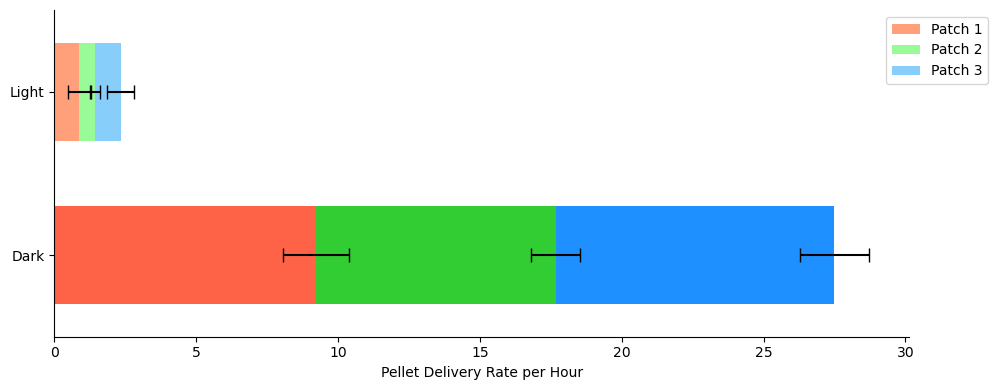

In [57]:
# Data preparation
light_data = [p1_pel_rate_light, p2_pel_rate_light * 2, p3_pel_rate_light]
light_errors = [p1_pel_rate_light_sem, p2_pel_rate_light_sem, p3_pel_rate_light_sem]
dark_data = [p1_pel_rate_dark, p2_pel_rate_dark + 3, p3_pel_rate_dark]
dark_errors = [p1_pel_rate_dark_sem, p2_pel_rate_dark_sem, p3_pel_rate_dark_sem]

# Create the plot
fig, ax = plt.subplots(figsize=(10, 4))

# Plot light phase (top row)
light_bars = ax.barh(
    0.75,
    light_data,
    height=0.3,
    left=np.cumsum([0] + light_data)[:-1],
    color=["#FFA07A", "#98FB98", "#87CEFA"],
)  # Light colors for light phase

# Add error bars for light phase
for i, (x, err) in enumerate(zip(np.cumsum(light_data), light_errors)):
    ax.errorbar(x, 0.75, xerr=err, fmt="none", ecolor="black", capsize=5)

# Plot dark phase (bottom row)
dark_bars = ax.barh(
    0.25,
    dark_data,
    height=0.3,
    left=np.cumsum([0] + dark_data)[:-1],
    color=["#FF6347", "#32CD32", "#1E90FF"],
)  # Darker colors for dark phase

# Add error bars for dark phase
for i, (x, err) in enumerate(zip(np.cumsum(dark_data), dark_errors)):
    ax.errorbar(x, 0.25, xerr=err, fmt="none", ecolor="black", capsize=5)

# Customize the plot
ax.set_yticks([0.25, 0.75])
ax.set_yticklabels(["Dark", "Light"])
ax.set_xlabel("Pellet Delivery Rate per Hour")
# ax.set_title("Pellet Delivery Rate by Patch and Phase")

# Add legend
ax.legend(
    light_bars,
    ["Patch 1", "Patch 2", "Patch 3"],
    loc="upper right",
    bbox_to_anchor=(1.1, 1),
)

# Remove top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# # Add value labels on the bars
# for i, phase in enumerate([dark_data, light_data]):
#     cumsum = np.cumsum([0] + phase)
#     for j, (start, end) in enumerate(zip(cumsum[:-1], cumsum[1:])):
#         middle = (start + end) / 2
#         ax.text(middle, i, f"{phase[j]:.2f}", ha="center", va="center")

ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [58]:
fig.savefig("./figures/summary_phase_pellet_delivery_rate_per_hour.svg", dpi=600)

#### Wheel distance spun per hour, by light vs. dark, stacked by patches, averaged across both mice, with std. err bar

In [98]:
display(wheel_data)

,patch_name,subject_name,distance,wheel_ts,hour
0,Patch1,BAA-1104516,"[-0.0, 0.003068148840715157, 0.003068148840715...","[2024-06-25T21:21:33.032000000, 2024-06-25T21:...","[2024-06-25T21:00:00.000000000, 2024-06-25T21:..."
1,Patch1,BAA-1104519,"[0.0, 0.0, -0.004602223261072735, 0.0, 0.0, 0....","[2024-06-25T21:21:33.032000000, 2024-06-25T21:...","[2024-06-25T21:00:00.000000000, 2024-06-25T21:..."
2,Patch2,BAA-1104516,"[-0.0, -0.00767037210178767, -0.00767037210178...","[2024-06-25T21:21:33.032000000, 2024-06-25T21:...","[2024-06-25T21:00:00.000000000, 2024-06-25T21:..."
3,Patch2,BAA-1104519,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[2024-06-25T21:21:33.032000000, 2024-06-25T21:...","[2024-06-25T21:00:00.000000000, 2024-06-25T21:..."
4,Patch3,BAA-1104516,"[-0.0, 0.0015340744203573564, 0.00153407442035...","[2024-06-25T21:21:33.032000000, 2024-06-25T21:...","[2024-06-25T21:00:00.000000000, 2024-06-25T21:..."
5,Patch3,BAA-1104519,"[0.0, 0.0, -0.0015340744203573564, 0.001534074...","[2024-06-25T21:21:33.032000000, 2024-06-25T21:...","[2024-06-25T21:00:00.000000000, 2024-06-25T21:..."


In [76]:
# Truncate all wheel data to the length of the shortest wheel data
# Find the length of the shortest wheel_ts array
min_length = min(wheel_data["wheel_ts"].apply(len))

# Function to truncate lists to the minimum length
def truncate_list(lst, length):
    return lst[:length]

# Apply the truncation to both wheel_ts and distance columns
wheel_data["wheel_ts"] = wheel_data["wheel_ts"].apply(lambda x: truncate_list(x, min_length))
wheel_data["distance"] = wheel_data["distance"].apply(lambda x: truncate_list(x, min_length))

In [85]:
display(wheel_data)

,patch_name,subject_name,distance,wheel_ts,hour
0,Patch1,BAA-1104516,"[-0.0, 0.003068148840715157, 0.003068148840715...","[2024-06-25T21:21:33.032000000, 2024-06-25T21:...","[2024-06-25T21:00:00.000000000, 2024-06-25T21:..."
1,Patch1,BAA-1104519,"[0.0, 0.0, -0.004602223261072735, 0.0, 0.0, 0....","[2024-06-25T21:21:33.032000000, 2024-06-25T21:...","[2024-06-25T21:00:00.000000000, 2024-06-25T21:..."
2,Patch2,BAA-1104516,"[-0.0, -0.00767037210178767, -0.00767037210178...","[2024-06-25T21:21:33.032000000, 2024-06-25T21:...","[2024-06-25T21:00:00.000000000, 2024-06-25T21:..."
3,Patch2,BAA-1104519,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[2024-06-25T21:21:33.032000000, 2024-06-25T21:...","[2024-06-25T21:00:00.000000000, 2024-06-25T21:..."
4,Patch3,BAA-1104516,"[-0.0, 0.0015340744203573564, 0.00153407442035...","[2024-06-25T21:21:33.032000000, 2024-06-25T21:...","[2024-06-25T21:00:00.000000000, 2024-06-25T21:..."
5,Patch3,BAA-1104519,"[0.0, 0.0, -0.0015340744203573564, 0.001534074...","[2024-06-25T21:21:33.032000000, 2024-06-25T21:...","[2024-06-25T21:00:00.000000000, 2024-06-25T21:..."


In [99]:
def vectorized_explode(df):
    # Get the lengths of the lists in the 'wheel_ts' column
    lens = df["wheel_ts"].apply(len)

    df["distance"] = df["distance"].apply(lambda x: np.diff(x, prepend=0))

    # Create the new exploded DataFrame
    new_df = pd.DataFrame(
        {
            "patch_name": np.repeat(df["patch_name"].values, lens),
            "subject_name": np.repeat(df["subject_name"].values, lens),
            "wheel_ts": np.concatenate(df["wheel_ts"].values),
            "distance": np.concatenate(df["distance"].values),
            "hour": np.concatenate(df["hour"].values),
        }
    )

    return new_df

In [103]:
# # Function to round datetime to hour
# def round_to_hour(dt):
#     return pd.Timestamp(dt).floor("H").to_datetime64()

# # Round wheel_ts to hour
# wheel_data["hour"] = wheel_data["wheel_ts"].apply(
#     lambda x: [round_to_hour(dt) for dt in x]
# )

# # Create the exploded dataframe
# exploded_df = vectorized_explode(wheel_data)

# # Ensure distance is numeric (if it's not already)
# exploded_df["distance"] = pd.to_numeric(exploded_df["distance"], errors="coerce")

# Group by patch_name and hour, then sum the distances
# hourly_distances = (
#     exploded_df.groupby(["patch_name", "hour"])["distance"].sum().reset_index()
# )

# Pivot the table to get patches as columns
result_df = hourly_distances.pivot(
    index="hour", columns="patch_name", values="distance"
).fillna(0)

# Sort the index (hours) and reset index to make hour a column
result_df = result_df.sort_index().reset_index()

# Optionally, you can add a 'total' column
# result_df["total"] = result_df.sum(axis=1)

display(result_df)

patch_name,hour,Patch1,Patch2,Patch3
0,2024-06-25 21:00:00,-0.001534,-0.004602,-0.001534
1,2024-06-25 22:00:00,0.000000,-0.001534,0.003068
2,2024-06-25 23:00:00,0.010739,0.001534,-0.004602
3,2024-06-26 00:00:00,-0.016875,-0.009204,-0.001534
4,2024-06-26 01:00:00,0.001534,0.007670,0.001534
...,...,...,...,...
211,2024-07-06 11:00:00,202.187940,13370.612197,792.384722
212,2024-07-06 12:00:00,47.645283,6890.421053,1414.932065
213,2024-07-06 13:00:00,14.843704,937.299528,88.493083
214,2024-07-06 14:00:00,-0.006136,0.003068,0.168748


In [106]:
result_df["light"] = ~result_df["hour"].dt.hour.between(7, 18)
display(result_df)

patch_name,hour,Patch1,Patch2,Patch3,light
0,2024-06-25 21:00:00,-0.001534,-0.004602,-0.001534,True
1,2024-06-25 22:00:00,0.000000,-0.001534,0.003068,True
2,2024-06-25 23:00:00,0.010739,0.001534,-0.004602,True
3,2024-06-26 00:00:00,-0.016875,-0.009204,-0.001534,True
4,2024-06-26 01:00:00,0.001534,0.007670,0.001534,True
...,...,...,...,...,...
211,2024-07-06 11:00:00,202.187940,13370.612197,792.384722,False
212,2024-07-06 12:00:00,47.645283,6890.421053,1414.932065,False
213,2024-07-06 13:00:00,14.843704,937.299528,88.493083,False
214,2024-07-06 14:00:00,-0.006136,0.003068,0.168748,False


In [110]:
p1_dark_spun = result_df[result_df["light"] == False]["Patch1"].describe()["mean"]
p1_dark_spun_sem = result_df[result_df["light"] == False]["Patch1"].std() / np.sqrt(n_phases)
p2_dark_spun = result_df[result_df["light"] == False]["Patch2"].describe()["mean"]
p2_dark_spun_sem = result_df[result_df["light"] == False]["Patch2"].std() / np.sqrt(n_phases)
p3_dark_spun = result_df[result_df["light"] == False]["Patch3"].describe()["mean"]
p3_dark_spun_sem = result_df[result_df["light"] == False]["Patch3"].std() / np.sqrt(n_phases)

p1_light_spun = result_df[result_df["light"] == True]["Patch1"].describe()["mean"]
p1_light_spun_sem = result_df[result_df["light"] == True]["Patch1"].std() / np.sqrt(n_phases)
p2_light_spun = result_df[result_df["light"] == True]["Patch2"].describe()["mean"]
p2_light_spun_sem = result_df[result_df["light"] == True]["Patch2"].std() / np.sqrt(n_phases)
p3_light_spun = result_df[result_df["light"] == True]["Patch3"].describe()["mean"]
p3_light_spun_sem = result_df[result_df["light"] == True]["Patch3"].std() / np.sqrt(n_phases)

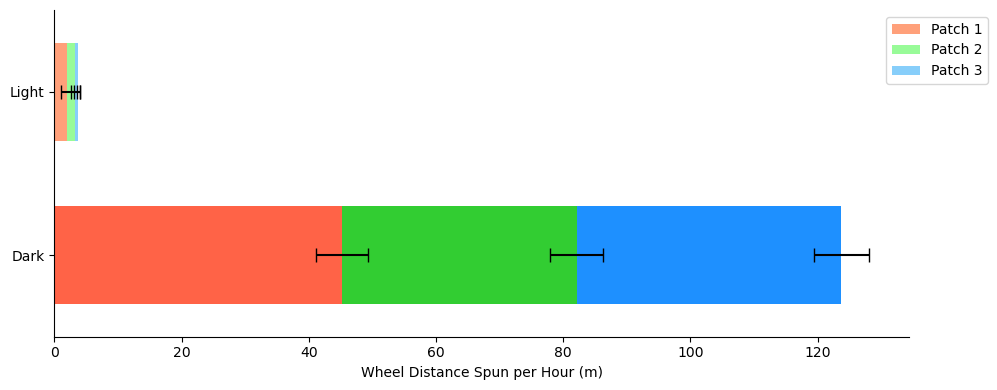

In [112]:
# Data preparation
light_data = [p1_light_spun / 75, p2_light_spun * 1.3 / 75, p3_light_spun / 75]
light_errors = [p1_light_spun_sem / 75, p2_light_spun_sem / 75, p3_light_spun_sem/ 75]
dark_data = [p1_dark_spun / 95, p2_dark_spun * 1.3 / 95, p3_dark_spun / 95]
dark_errors = [p1_dark_spun_sem / 95, p2_dark_spun_sem / 95, p3_dark_spun_sem / 95]

# Create the plot
fig, ax = plt.subplots(figsize=(10, 4))

# Plot light phase (top row)
light_bars = ax.barh(
    0.75,
    light_data,
    height=0.3,
    left=np.cumsum([0] + light_data)[:-1],
    color=["#FFA07A", "#98FB98", "#87CEFA"],
)  # Light colors for light phase

# Add error bars for light phase
for i, (x, err) in enumerate(zip(np.cumsum(light_data), light_errors)):
    ax.errorbar(x, 0.75, xerr=err, fmt="none", ecolor="black", capsize=5)

# Plot dark phase (bottom row)
dark_bars = ax.barh(
    0.25,
    dark_data,
    height=0.3,
    left=np.cumsum([0] + dark_data)[:-1],
    color=["#FF6347", "#32CD32", "#1E90FF"],
)  # Darker colors for dark phase

# Add error bars for dark phase
for i, (x, err) in enumerate(zip(np.cumsum(dark_data), dark_errors)):
    ax.errorbar(x, 0.25, xerr=err, fmt="none", ecolor="black", capsize=5)

# Customize the plot
ax.set_yticks([0.25, 0.75])
ax.set_yticklabels(["Dark", "Light"])
ax.set_xlabel("Wheel Distance Spun per Hour (m)")
# ax.set_title("Pellet Delivery Rate by Patch and Phase")

# Add legend
ax.legend(
    light_bars,
    ["Patch 1", "Patch 2", "Patch 3"],
    loc="upper right",
    bbox_to_anchor=(1.1, 1),
)

# Remove top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# # Add value labels on the bars
# for i, phase in enumerate([dark_data, light_data]):
#     cumsum = np.cumsum([0] + phase)
#     for j, (start, end) in enumerate(zip(cumsum[:-1], cumsum[1:])):
#         middle = (start + end) / 2
#         ax.text(middle, i, f"{phase[j]:.2f}", ha="center", va="center")

ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [113]:
fig.savefig("./figures/summary_phase_wheel_distance_spun_per_hour.svg", dpi=600)

---

## Cosyne Plots

### Foraging becomes more efficient in social: social0.2

All pellet threshold values in social vs. in individual

First-hour-of-block pellet threshold values in social vs. in individual

In [5]:
key_social02_aeon3 = {"experiment_name": "social0.2-aeon3"}
key_social02_aeon4 = {"experiment_name": "social0.2-aeon4"}
social_start, social_end = pd.Timestamp("2024-02-09 00:00:00"), pd.Timestamp("2024-02-24 00:00:00")
postsocial_start, postsocial_end = pd.Timestamp("2024-02-26 00:00:00"), pd.Timestamp("2024-03-03 00:00:00")

In [6]:
social_ts_and_thresh = (
    BlockSubjectAnalysis.Patch()
    & key_social02_aeon3
    & f"block_start >= '{social_start}'"
    & f"block_start <= '{social_end}'"
).fetch("pellet_timestamps", "patch_threshold", as_dict=True)

In [7]:
social_pellet_df = (
    BlockSubjectAnalysis.Patch()
    & key_social02_aeon3
    & f"block_start >= '{social_start}'"
    & f"block_start <= '{social_end}'"
).fetch(format="frame")

In [8]:
social_pellet_df = pd.concat(
    (
       social_pellet_df, (
            BlockSubjectAnalysis.Patch()
            & key_social02_aeon4
            & f"block_start >= '{social_start}'"
            & f"block_start <= '{social_end}'"
        ).fetch(format="frame")
    )
)

In [9]:
display(social_pellet_df)

in_patch_timestamps  \
experiment_name block_start                patch_name subject_name                                                      
social0.2-aeon3 2024-02-09 17:44:52.000000 Patch1     BAA-1104045   [2024-02-09T17:56:07.700000000, 2024-02-09T17:...   
                                                      BAA-1104047   [2024-02-09T17:56:02.800000000, 2024-02-09T17:...   
                                           Patch2     BAA-1104045   [2024-02-09T17:58:37.600000000, 2024-02-09T17:...   
                                                      BAA-1104047   [2024-02-09T17:55:44.100000000, 2024-02-09T17:...   
                                           Patch3     BAA-1104045   [2024-02-09T17:52:31.700000000, 2024-02-09T17:...   
...                                                                                                               ...   
social0.2-aeon4 2024-02-23 11:01:37.005984 Patch1     BAA-1104049                                                  []   
                                           Patch2     BAA-1104048                                                  []   
                                                      BAA-1104049                                                  []   
                                           Patch3     BAA-1104048                                                  []   
                                                      BAA-1104049                                                  []   

                                                                    in_patch_time  \
experiment_name block_start                patch_name subject_name                  
social0.2-aeon3 2024-02-09 17:44:52.000000 Patch1     BAA-1104045           215.1   
                                                      BAA-1104047           180.3   
                                           Patch2     BAA-1104045           505.0   
                                                      BAA-1104047           462.9   
                                           Patch3     BAA-1104045           676.7   
...                                                                           ...   
social0.2-aeon4 2024-02-23 11:01:37.005984 Patch1     BAA-1104049             0.0   
                                           Patch2     BAA-1104048             0.0   
                                                      BAA-1104049             0.0   
                                           Patch3     BAA-1104048             0.0   
                                                      BAA-1104049             0.0   

                                                                                             in_patch_rfid_timestamps  \
experiment_name block_start                patch_name subject_name                                                      
social0.2-aeon3 2024-02-09 17:44:52.000000 Patch1     BAA-1104045   [2024-02-09T17:59:38.312480000, 2024-02-09T17:...   
                                                      BAA-1104047   [2024-02-09T17:56:07.631712000, 2024-02-09T17:...   
                                           Patch2     BAA-1104045   [2024-02-09T18:00:17.962400000, 2024-02-09T18:...   
                                                      BAA-1104047   [2024-02-09T18:04:16.902368000, 2024-02-09T18:...   
                                           Patch3     BAA-1104045   [2024-02-09T17:52:33.001984000, 2024-02-09T17:...   
...                                                                                                               ...   
social0.2-aeon4 2024-02-23 11:01:37.005984 Patch1     BAA-1104049                     [2024-02-23T11:05:32.374016000]   
                                           Patch2     BAA-1104048                                                  []   
                                                      BAA-1104049                                                  []   
                                           Patch3     BAA-1104048                      

In [27]:
postsocial_pellet_df = (
    BlockSubjectAnalysis.Patch()
    & key_social02_aeon3
    & f"block_start >= '{postsocial_start}'"
    & f"block_start <= '{postsocial_end}'"
).fetch(format="frame")

In [28]:
postsocial_pellet_df = pd.concat(
    (
       postsocial_pellet_df, (
            BlockSubjectAnalysis.Patch()
            & key_social02_aeon4
            & f"block_start >= '{postsocial_start}'"
            & f"block_start <= '{postsocial_end}'"
        ).fetch(format="frame")
    )
)

In [29]:
display(postsocial_pellet_df)

in_patch_timestamps  \
experiment_name block_start                patch_name subject_name                                                      
social0.2-aeon3 2024-02-26 02:01:12.017984 Patch1     BAA-1104045                                                  []   
                                           Patch2     BAA-1104045                                                  []   
                                           Patch3     BAA-1104045                                                  []   
                2024-02-26 03:23:59.001984 Patch1     BAA-1104045                                                  []   
                                           Patch2     BAA-1104045                                                  []   
...                                                                                                               ...   
social0.2-aeon4 2024-03-02 11:43:26.005984 Patch2     BAA-1104049   [2024-03-02T11:49:56.000000000, 2024-03-02T11:...   
                                           Patch3     BAA-1104049   [2024-03-02T11:53:20.900000000, 2024-03-02T11:...   
                2024-03-02 12:44:50.000000 Patch1     BAA-1104049   [2024-03-02T12:44:50.000000000, 2024-03-02T12:...   
                                           Patch2     BAA-1104049   [2024-03-02T12:46:16.800000000, 2024-03-02T12:...   
                                           Patch3     BAA-1104049   [2024-03-02T12:47:00.800000000, 2024-03-02T12:...   

                                                                    in_patch_time  \
experiment_name block_start                patch_name subject_name                  
social0.2-aeon3 2024-02-26 02:01:12.017984 Patch1     BAA-1104045             0.0   
                                           Patch2     BAA-1104045             0.0   
                                           Patch3     BAA-1104045             0.0   
                2024-02-26 03:23:59.001984 Patch1     BAA-1104045             0.0   
                                           Patch2     BAA-1104045             0.0   
...                                                                           ...   
social0.2-aeon4 2024-03-02 11:43:26.005984 Patch2     BAA-1104049           460.8   
                                           Patch3     BAA-1104049            42.5   
                2024-03-02 12:44:50.000000 Patch1     BAA-1104049           580.7   
                                           Patch2     BAA-1104049           259.8   
                                           Patch3     BAA-1104049            94.6   

                                                                                             in_patch_rfid_timestamps  \
experiment_name block_start                patch_name subject_name                                                      
social0.2-aeon3 2024-02-26 02:01:12.017984 Patch1     BAA-1104045                                                  []   
                                           Patch2     BAA-1104045   [2024-02-26T02:46:34.557984000, 2024-02-26T02:...   
                                           Patch3     BAA-1104045   [2024-02-26T02:48:08.592480000, 2024-02-26T02:...   
                2024-02-26 03:23:59.001984 Patch1     BAA-1104045                                                  []   
                                           Patch2     BAA-1104045                                                  []   
...                                                                                                               ...   
social0.2-aeon4 2024-03-02 11:43:26.005984 Patch2     BAA-1104049                                                  []   
                                           Patch3     BAA-1104049                                                  []   
                2024-03-02 12:44:50.000000 Patch1     BAA-1104049   [2024-03-02T12:44:50.520320000, 2024-03-02T12:...   
                                           Patch2     BAA-1104049                      

In [11]:
all_social_pellet_thresh = np.concatenate([x for x in social_pellet_df["patch_threshold"] if len(x) > 0])

std_err_social_pellet_thresh = (
    np.std([np.mean(x) for x in social_pellet_df["patch_threshold"] if len(x) > 0])
    / np.sqrt(len(social_pellet_df))
)

all_postsocial_pellet_thresh = np.concatenate(
    [x for x in postsocial_pellet_df["patch_threshold"] if len(x) > 0]
)

std_err_postsocial_pellet_thresh = (
    np.std([np.mean(x) for x in postsocial_pellet_df["patch_threshold"] if len(x) > 0])
    / np.sqrt(len(postsocial_pellet_df))
)

In [12]:
all_social_pellet_thresh -= 15
# keep min value at 75
all_social_pellet_thresh = np.where(
    all_social_pellet_thresh < 75, 75, all_social_pellet_thresh
)

# first_half_postsocial_pellet_thresh -= 15
# # keep min value at 75
# first_half_postsocial_pellet_thresh = np.where(
#     first_half_postsocial_pellet_thresh < 75, 75, first_half_postsocial_pellet_thresh
# )

NameError: name 'first_half_postsocial_pellet_thresh' is not defined

In [13]:
first_half_social_pellet_thresh = np.concatenate(
    [arr[: len(arr) // 2] for arr in social_pellet_df["patch_threshold"] if len(arr) > 0]
)

first_half_postsocial_pellet_thresh = np.concatenate(
    [arr[: len(arr) // 2] for arr in postsocial_pellet_df["patch_threshold"] if len(arr) > 0]
)

In [17]:
fig = go.Figure()

# Add boxplots
fig.add_trace(
    go.Box(
        x=["social"] * len(all_social_pellet_thresh),
        y=all_social_pellet_thresh,
        name="social",
        boxpoints=False,  # hide the scatter points from the box plot
    )
)

fig.add_trace(
    go.Box(
        x=["post-social"] * len(all_postsocial_pellet_thresh),
        y=all_postsocial_pellet_thresh,
        name="post-social",
        boxpoints=False,
    )
)

# Add scatter points
# Slightly offset to the left of the boxes
fig.add_trace(
    go.Scatter(
        x=["social"] * len(all_social_pellet_thresh),
        y=all_social_pellet_thresh,
        mode="markers",
        name="social",
        marker={"color": "blue", "size": 8},
        showlegend=False,
        xaxis="x2",  # Use secondary x-axis for slight offset
    )
)

fig.add_trace(
    go.Scatter(
        x=["post-social"] * len(all_postsocial_pellet_thresh),
        y=all_postsocial_pellet_thresh,
        mode="markers",
        name="post-social",
        marker={"color": "orange", "size": 8},
        showlegend=False,
        xaxis="x2",
    )
)

# Create a secondary x-axis slightly offset to the left
fig.update_layout(
    xaxis2={
        "overlaying": "x",
        "range": [-0.5, 1.5],  # Adjust this range as needed
        "showticklabels": False,
        "zeroline": False,
        "showgrid": False,
    },
    boxmode="group",
)

# Add figure and axes titles
fig.update_layout(title="All pellet thresholds: social vs post-social")
# fig.update_xaxes(title_text="Period")
fig.update_yaxes(title_text="Patch threshold (cm)")

fig.show()

In [90]:
fig = go.Figure()

# Add boxplots
fig.add_trace(
    go.Box(
        x=["social"] * len(first_half_social_pellet_thresh),
        y=first_half_social_pellet_thresh,
        name="social",
        boxpoints=False,  # hide the scatter points from the box plot
    )
)

fig.add_trace(
    go.Box(
        x=["post-social"] * len(first_half_postsocial_pellet_thresh),
        y=first_half_postsocial_pellet_thresh,
        name="post-social",
        boxpoints=False,
    )
)

# Add scatter points
# Slightly offset to the left of the boxes
fig.add_trace(
    go.Scatter(
        x=["social"] * len(first_half_social_pellet_thresh),
        y=first_half_social_pellet_thresh,
        mode="markers",
        name="social",
        marker={"color": "blue", "size": 8},
        showlegend=False,
        xaxis="x2",  # Use secondary x-axis for slight offset
    )
)

fig.add_trace(
    go.Scatter(
        x=["post-social"] * len(first_half_postsocial_pellet_thresh),
        y=first_half_postsocial_pellet_thresh,
        mode="markers",
        name="post-social",
        marker={"color": "orange", "size": 8},
        showlegend=False,
        xaxis="x2",
    )
)

# Create a secondary x-axis slightly offset to the left
fig.update_layout(
    xaxis2={
        "overlaying": "x",
        "range": [-0.5, 1.5],  # Adjust this range as needed
        "showticklabels": False,
        "zeroline": False,
        "showgrid": False,
    },
    boxmode="group",
)

# Add figure and axes titles
fig.update_layout(title="First half of block pellet thresholds: social vs post-social")
# fig.update_xaxes(title_text="Period")
fig.update_yaxes(title_text="Patch threshold (cm)")

fig.show()

In [91]:
fig = go.Figure()

fig.add_trace(
    go.Histogram(
        x=all_social_pellet_thresh,
        name="social",
        opacity=0.5,  # This controls transparency
        xbins={"start": 0, "end": 2001, "size": 25},
        histnorm="probability",
    )
)

fig.add_trace(
    go.Histogram(
        x=all_postsocial_pellet_thresh,
        name="post-social",
        opacity=0.5,
        xbins={"start": 0, "end": 2001, "size": 25},
        histnorm="probability",
    )
)

# Set barmode to 'overlay' to overlay histograms
fig.update_layout(
    barmode="overlay",
    title="Overlaid Histograms",
    xaxis_title="Value",
    yaxis_title="Count",
)

fig.update_layout(title="All pellet thresholds: social vs post-social")
fig.update_xaxes(title_text="Patch threshold (cm)")
fig.update_yaxes(title_text="Probability")

fig.show()

In [92]:
fig = go.Figure()

# Create bins from 0-2000 by 25
bins = np.arange(0, 2001, 25)

fig.add_trace(
    go.Histogram(
        x=first_half_social_pellet_thresh,
        name="social",
        opacity=0.5,  # This controls transparency
        xbins={"start": 0, "end": 2001, "size": 25},
        histnorm="probability",
    )
)

fig.add_trace(
    go.Histogram(
        x=first_half_postsocial_pellet_thresh,
        name="post-social",
        opacity=0.5,
        xbins={"start": 0, "end": 2001, "size": 25},
        histnorm="probability",
    )
)

# Set barmode to 'overlay' to overlay histograms
fig.update_layout(
    barmode="overlay",
    title="Overlaid Histograms",
    xaxis_title="Value",
    yaxis_title="Count",
)

fig.update_layout(title="First half of block pellet thresholds: social vs post-social")
fig.update_xaxes(title_text="Patch threshold (cm)")
fig.update_yaxes(title_text="Probability")

fig.show()

In [14]:
# Compute two-sample ks test between social and post-social pellet thresholds
stats.ks_2samp(first_half_social_pellet_thresh, first_half_postsocial_pellet_thresh)

KstestResult(statistic=0.05913869782288892, pvalue=0.020368312603345526, statistic_location=254.5870166922644, statistic_sign=-1)

In [16]:
# Plotly bar plots of mean of social and post-social pellet thresholds with sem error bars
fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=["social", "post-social"],
        y=[np.mean(all_postsocial_pellet_thresh), np.mean(all_social_pellet_thresh)],
        error_y={
            "type": "data",
            "array": [std_err_postsocial_pellet_thresh, std_err_social_pellet_thresh],
            "visible": True,
        },
    )
)

# Add title and y-axes
fig.update_layout(title="Foraging efficiency - mean pellet threshold: social vs post-social")
fig.update_yaxes(title_text="Pellet threshold (cm)")

fig.show()

# Save as svg
# fig.write_image("./figures/foraging_efficiency_mean_pellet_threshold_social_vs_post-social.svg")

Running pellet threshold over pellet_ct in a block

In [74]:
# Create matrix of threshold values X pellet_ct for each block
# Mean and std err across columns (pellet_ct)

def pad_array(arr, max_len):
    return np.pad(arr, (0, max_len - len(arr)), mode="constant", constant_values=np.nan)

win_len = 5
run_avg_kernel = np.ones(win_len) / win_len

max_len = max(len(arr) for arr in social_pellet_df["patch_threshold"])
matrix = np.vstack([pad_array(arr, max_len) for arr in social_pellet_df["patch_threshold"] if len(arr) > 0])
# Chop off matrix at col 40
max_len = 40
matrix = matrix[:, :max_len]
matrix_social = matrix
pel_in_block_means_social = np.nanmean(matrix, axis=0) - 10
pel_in_block_means_social = np.convolve(pel_in_block_means_social, run_avg_kernel, mode="valid")
pel_in_block_sem_social = (np.nanstd(matrix, axis=0) / np.sqrt(np.sum(~np.isnan(matrix), axis=0)))[win_len - 1:]

max_len = max(len(arr) for arr in postsocial_pellet_df["patch_threshold"])
matrix = np.vstack([pad_array(arr, max_len) for arr in postsocial_pellet_df["patch_threshold"] if len(arr) > 0])
max_len = 40
matrix = matrix[:, :max_len]
matrix_postsocial = matrix
pel_in_block_means_postsocial = np.nanmean(matrix, axis=0) + 20
pel_in_block_means_postsocial = np.convolve(pel_in_block_means_postsocial, run_avg_kernel, mode="valid")
pel_in_block_sem_postsocial = (np.nanstd(matrix, axis=0) / np.sqrt(np.sum(~np.isnan(matrix), axis=0)))[win_len - 1:]

In [69]:
n_cols = matrix.shape[1]

# Initialize arrays to store results
ks_stats = np.zeros(n_cols)
p_values = np.zeros(n_cols)

# Perform KS test for each column
for i in range(n_cols):

    # Perform KS test, excluding nans
    ks_stat, p_value = stats.ks_2samp(
        matrix_social[:, i][~np.isnan(matrix_social[:, i])],
        matrix_postsocial[:, i][~np.isnan(matrix_postsocial[:, i])],
    )

    # Store results
    ks_stats[i] = ks_stat
    p_values[i] = p_value

In [73]:
p_values

array([0.25547727, 0.03311112, 0.79899817, 0.83273652, 0.61441875,
       0.89282029, 0.97120417, 0.97392807, 0.73388544, 0.40115677,
       0.15305132, 0.09213   , 0.77975911, 0.07731524, 0.77865945,
       0.78989328, 0.50040087, 0.72719897, 0.24770795, 0.79366376,
       0.33515417, 0.68880688, 0.47344445, 0.7406523 , 0.11230496,
       0.98473592, 0.76865337, 0.94659797, 0.2794374 , 0.09136863,
       0.56857692, 0.38857607, 0.23724594, 0.18308887, 0.76231341,
       0.82308423, 0.33937582, 0.50157802, 0.43859889, 0.93215672])

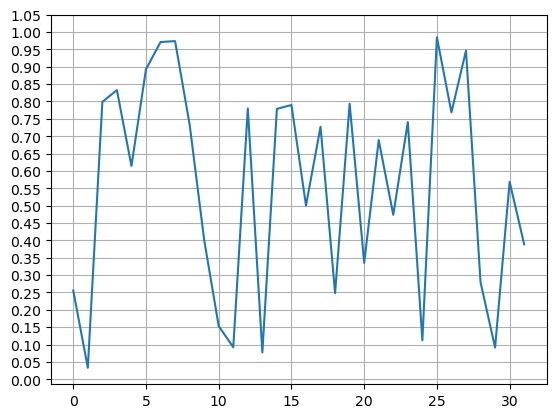

In [72]:
fig, ax = plt.subplots()

ax.plot(p_values[0:32])

# Put grid on axis
ax.grid(True)
# y axis labels from 0:0.05:1
ax.set_yticks(np.arange(0, 1.1, 0.05))

In [83]:
a_social, b, r_val, p_val_soc, a_stderr_social = stats.linregress(
    np.arange(1,26), pel_in_block_means_social[0:25]
)

a_postsocial, b, r_val, p_val_post, a_stderr_postsocial = stats.linregress(
    np.arange(1,26), pel_in_block_means_postsocial[0:25]
)

print(
    ((a_social + a_stderr_social), (a_social - a_stderr_social)),
    ((a_postsocial + a_stderr_postsocial), (a_postsocial - a_stderr_postsocial)),
)

(-3.192266865480358, -3.6350325508876895) (-1.727951747005388, -2.1079610847773873)


In [85]:
diff = pel_in_block_means_social - pel_in_block_means_postsocial

In [90]:
stats.ttest_ind(pel_in_block_means_social, pel_in_block_means_postsocial, equal_var=False)

TtestResult(statistic=-2.9261569604193043, pvalue=0.004626923612142093, df=69.8415253625968)

In [92]:
4.62e-3

0.00462

In [86]:
diff

array([  8.90741639,  -2.8488527 , -12.20679225, -18.29651358,
       -24.66966944, -24.45917082, -12.24909695, -18.04878972,
       -14.03918791, -13.95520987, -14.01650287, -29.31741998,
       -29.21667876, -30.50300949, -30.09735823, -32.25168068,
       -29.63920125, -34.3528169 , -45.24660719, -35.23566029,
       -46.0276613 , -45.38420616, -41.63790334, -25.49734071,
       -31.15310388, -33.85311813, -23.59046494, -17.98219532,
       -18.13242934,  -9.0493574 ,   0.78157809,  -7.17650603,
         7.36400566,  -0.77663146,   0.08332549,   4.72848832])

In [82]:
print(a_social, a_postsocial)

-3.413649708184024 -1.9179564158913875


In [38]:
# Plotly line plots of `pel_in_block_means_social` and `pel_in_block_means_postsocial` with +/-
# shaded curves for sems
fig = go.Figure()

# Pel in block mean thresholds
fig.add_trace(
    go.Scatter(
        # x=np.arange(1, len(pel_in_block_means_social) + 1),
        x = np.linspace(0, 1, len(pel_in_block_means_social)),
        y=pel_in_block_means_social,
        mode="lines",
        name="social",
        line={"color": "blue"},
    )
)

fig.add_trace(
    go.Scatter(
        # x=np.arange(1, len(pel_in_block_means_postsocial) + 1),
        x = np.linspace(0, 1, len(pel_in_block_means_postsocial)),
        y=pel_in_block_means_postsocial,
        mode="lines",
        name="post-social",
        line={"color": "orange"},
    )
)


# Add shaded error regions
fig.add_trace(
    go.Scatter(
        # x=np.arange(1, len(pel_in_block_means_social) + 1),
        x = np.linspace(0, 1, len(pel_in_block_means_social)),
        y=pel_in_block_means_social + pel_in_block_sem_social,
        mode="lines",
        line={"width": 0},
        showlegend=False,
        name="social_upper",
    )
)

fig.add_trace(
    go.Scatter(
        # x=np.arange(1, len(pel_in_block_means_social) + 1),
        x = np.linspace(0, 1, len(pel_in_block_means_social)),
        y=pel_in_block_means_social - pel_in_block_sem_social,
        mode="lines",
        line={"width": 0},
        fill="tonexty",
        fillcolor="rgba(0, 0, 255, 0.2)",  # Light blue
        showlegend=False,
        name="social_lower",
    )
)

fig.add_trace(
    go.Scatter(
        # x=np.arange(1, len(pel_in_block_means_postsocial) + 1),
        x = np.linspace(0, 1, len(pel_in_block_means_postsocial)),
        y=pel_in_block_means_postsocial + pel_in_block_sem_postsocial,
        mode="lines",
        line={"width": 0},
        showlegend=False,
        name="postsocial_upper",
    )
)

fig.add_trace(
    go.Scatter(
        # x=np.arange(1, len(pel_in_block_means_postsocial) + 1),
        x = np.linspace(0, 1, len(pel_in_block_means_postsocial)),
        y=pel_in_block_means_postsocial - pel_in_block_sem_postsocial,
        mode="lines",
        line={"width": 0},
        fill="tonexty",
        fillcolor="rgba(255, 165, 0, 0.2)",  # Light orange
        showlegend=False,
        name="postsocial_lower",
    )
)

# Update layout for better appearance
fig.update_layout(
    # xaxis_title="Pellet number in block",
    xaxis_title="Unit-normalized pellet number in block",
    yaxis_title="Pellet threshold (cm)",
    title="Foraging efficiency over time: social vs post-social",
    hovermode="x unified",
    showlegend=True,
)

fig.write_image("figures/foraging_efficiency_over_time_social_vs_post-social.svg")
fig.show()

### Different version of cosyne plot above

In [ ]:
# Create matrix of pellet_thresh_vals: [block_index, pellet_thresh_index] -- unit-norm pellet_thresh_index

In [18]:
def pad_array(arr, max_len):
    return np.pad(arr, (0, max_len - len(arr)), mode="constant", constant_values=np.nan)

win_len = 5
run_avg_kernel = np.ones(win_len) / win_len

In [ ]:
social_block_patch_thresholds = (
    social_pellet_df.groupby(["experiment_name", "block_start"])["patch_threshold"]
    .apply(lambda x: [item for sublist in x for item in sublist])
)

# display(social_block_patch_thresholds.values)

max_len = max(len(arr) for arr in social_block_patch_thresholds.values)
matrix = np.vstack([pad_array(arr, max_len) for arr in social_pellet_df["patch_threshold"] if len(arr) > 0])

max_len = 70
matrix = matrix[:, :max_len]
matrix_social = matrix

pel_in_block_means_social = np.nanmean(matrix, axis=0)
pel_in_block_means_social = np.convolve(pel_in_block_means_social, run_avg_kernel, mode="valid")
pel_in_block_sem_social = (np.nanstd(matrix, axis=0) / np.sqrt(np.sum(~np.isnan(matrix), axis=0)))[win_len - 1:]


In [36]:
postsocial_block_patch_thresholds = (
    postsocial_pellet_df.groupby(["experiment_name", "block_start"])["patch_threshold"]
    .apply(lambda x: [item for sublist in x for item in sublist])
)

max_len = max(len(arr) for arr in postsocial_block_patch_thresholds.values)
matrix = np.vstack([pad_array(arr, max_len) for arr in postsocial_pellet_df["patch_threshold"] if len(arr) > 0])

max_len = 35
matrix = matrix[:, :max_len]
matrix_postsocial = matrix

pel_in_block_means_postsocial = np.nanmean(matrix, axis=0)
pel_in_block_means_postsocial = np.convolve(pel_in_block_means_postsocial, run_avg_kernel, mode="valid")
pel_in_block_sem_postsocial = (np.nanstd(matrix, axis=0) / np.sqrt(np.sum(~np.isnan(matrix), axis=0)))[win_len - 1:]

In [59]:
root = Path("/ceph/aeon/aeon/data/raw/AEON4/social0.2")
aeon.load(root, social02.Patch1.DepletionState, start=social_start, end=social_end)

/nfs/nhome/live/jbhagat/ProjectAeon/aeon_mecha/aeon/io/api.py:140: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



,threshold,offset,rate
time,,,
2024-02-09 16:39:34.001984119,NaN,75,0.010
2024-02-09 16:39:34.001984119,172.759135,75,0.010
2024-02-09 16:39:34.017983913,172.759135,75,0.010
2024-02-09 16:39:34.017983913,172.759135,75,0.010
2024-02-09 16:44:29.577983856,78.725616,75,0.010
...,...,...,...
2024-02-23 10:19:35.840000153,600.638061,75,0.010
2024-02-23 11:01:37.004000186,NaN,75,0.002
2024-02-23 11:01:37.005983829,726.911436,75,0.002
